# **E-commerce Sales Analytics using SQL, Python, and Tableau**

This project analyzes sales performance and customer behavior using an end-to-end analytics workflow. The analysis includes SQL data extraction, exploratory data analysis (EDA), statistical analysis in Python, and interactive dashboard development in Tableau to generate actionable business insights.


The dataset created by the request contains the following fields  
**date** - дата замовлення  
**ga_session_id** - ідентифікатор сесії  
**continent** - континент  
**country** - країна   
**device** - девайс   
**browser** - браузер   
**mobile_model_name** - назва моделі пристрою   
**operating_system** - операційна система   
**language** - мова браузера   
**сhannel_source** - інформація про джерело трафіку   
**channel** - канал трафіку   
**account_id** - ідентифікатор зареєстрованого користувача   
**email_is_verified**- чи підтвердив користувач свій  
**is_unsubscribed** - чи підписався користувач на розсилку   
**category** - категорія товару   
**product_name** - назва товару  
**price** - ціна   
**short_description** - короткий опис товару

#**1. Connecting to [Database in Google BigQuery](https://console.cloud.google.com/bigquery?authuser=0&project=data-analytics-mate&supportedpurview=project&ws=!1m4!1m3!3m2!1sdata-analytics-mate!2sDA&pli=1&inv=1&invt=Abhd_A) (DA dataset).**

In [ ]:
# 1. Installing a library to work with Google BigQuery
!pip install -q google-cloud-bigquery

In [ ]:
# 2. Connecting Libraries
from google.cloud import bigquery
from google.colab import auth
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.express as px
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import shapiro, ttest_rel, wilcoxon
from scipy.stats import chisquare
from scipy.stats import kruskal
from statsmodels.stats.proportion import proportions_ztest



In [ ]:
#3. Authentication in Big Query
auth.authenticate_user()
#4. Creating Client in Big Query
client = bigquery.Client(project="data-analytics-mate")
print("BigQuery client created successfully")

BigQuery client created successfully


In [ ]:
# 4. Creating SQL-query
query = """
SELECT s.date,
       s.ga_session_id,
       sp.continent,
       sp.country,
       sp.device,
       sp.browser,
       sp.mobile_model_name,
       sp.operating_system,
       sp.language,
       sp.name AS channel_source,
       sp.channel,
       acs.account_id,
       ac.is_verified,
       ac.is_unsubscribed,
       p.category,
       p.name AS product_name,
       p.price,
       p.short_description
FROM `DA.session` AS s
LEFT JOIN `DA.session_params` AS sp
ON s.ga_session_id=sp.ga_session_id
LEFT JOIN `DA.account_session` AS acs
ON s.ga_session_id=acs.ga_session_id
LEFT JOIN `DA.account` AS ac
ON acs.account_id=ac.id
LEFT JOIN `DA.order` AS o
ON s.ga_session_id=o.ga_session_id
LEFT JOIN `DA.product` AS p
ON o.item_id=p.item_id
"""
# Executing the query
result_query = client.query(query)
# Converting results of query to a DataFrame
df = result_query.to_dataframe()
df.head()

,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,channel_source,channel,account_id,is_verified,is_unsubscribed,category,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


# **2. Exploratory Data Analisis**

## **2.1 Data description**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   channel_source     349545 non-null  object 
 10  channel            349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  product_name       33538 non-null   object 
 16  pr

In [ ]:
df.shape

(349545, 18)

In [ ]:
unique_sessions = df['ga_session_id'].nunique()
print(f"Number of unique_sessions: {unique_sessions}")

Number of unique_sessions: 349545


*   Датасет має 349545 рядків, зокрема, містить дані про 349545 унікальних сесій користовувчів.
*   Датасет складається з 18  полів, з яких 4 поля (ga_session_id, account_id, is_verified, is_unsubscribed) - числові цілого типу, одне поле (price) - числове поле дійсного типу, одне поле (date) - типу дата, 12 полів (continent, country, device, browser, mobile_model_name, operating_system, language, channel_source, channel, category, product_name, short_description) - типу object.

  


In [ ]:
start_date = df['date'].min()
end_date = df['date'].max()
duration_days = (end_date - start_date).days

print(f"Початок періоду: {start_date}")
print(f"Кінець періоду: {end_date}")
print(f"Тривалість в днях: {duration_days}")

Початок періоду: 2020-11-01
Кінець періоду: 2021-01-31
Тривалість в днях: 91


## **2.2 Checking data quality (missing values and duplicates)**

In [ ]:
eda = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isna().sum(),
    '% missing': (df.isna().mean() * 100).round(1),
    'unique_values': df.nunique(),
    'sample_value': df.iloc[0]
}).sort_values('% missing', ascending=False)

eda

,dtype,missing_count,% missing,unique_values,sample_value
is_unsubscribed,Int64,321600,92.0,2,<NA>
is_verified,Int64,321600,92.0,2,<NA>
account_id,Int64,321600,92.0,27945,<NA>
short_description,object,316007,90.4,1476,"Shelving unit with laptop table, 202x36x175 cm"
product_name,object,316007,90.4,550,VITTSJÖ
category,object,316007,90.4,14,Bookcases & shelving units
price,float64,316007,90.4,829,609.0
language,object,114266,32.7,9,zh
ga_session_id,Int64,0,0.0,349545,5760483956
date,dbdate,0,0.0,92,2020-11-01


*   Типи даних відповідають характеру даних у відповідних колонках, перетворень не потребують.
*   Найбільше пропущених значень знаходиться в полях, що стосуються акаунта користувача (account_id, is_veryfied, is_unsubscribe) - 92%, що вказує на наявність значної кількості сесій без створення акаунта для здійснення покупки. Пропущені значення в полях, що відносяться до продукту (category, product_name, price, short_description) - 90% пропущених значень, вказують на те, що далеко не всі сесії користувача закінчуються покупкою. Пропущені значення також є в полі language (мова браузера) - біля 33%.

In [ ]:
print(df.duplicated().sum())

0


*   сума логічних значень дорівнює нулю, що означає, що всі значення False, а отже, дублікати відсутні.

## **2.3 Descriptive statistics**

In [ ]:
df[['category', 'product_name', 'continent','country', 'device', 'browser', 'language', 'operating_system', 'mobile_model_name', 'channel',  'channel_source']].describe(include='object')

,category,product_name,continent,country,device,browser,language,operating_system,mobile_model_name,channel,channel_source
count,33538,33538,349545,349545,349545,349545,235279,349545,349545,349545,349545
unique,14,550,6,108,3,6,9,6,10,5,5
top,Bookcases & shelving units,BESTÅ,Americas,United States,desktop,Chrome,en-us,Web,Chrome,Organic Search,(organic)
freq,7630,1257,193179,153470,204429,238460,159893,203909,97254,124425,119024


*   Найбільше сесій у датасеті припадає на користувачів з Північної та Південної Америки, зокрема зі США, які переважно використовують настільні пристрої та браузер Chrome. Основним джерелом трафіку є Organic Search, а найпоширенішою мовою інтерфейсу є en-us, що також підтверджує домінування англомовної аудиторії. Серед товарів найпопулярнішим є продукт BESTÅ, який належить до категорії Bookcases & shelving units.

In [ ]:
df['price'].describe().round(2)

,price
count,33538.0
mean,953.3
std,1317.0
min,3.0
25%,170.0
50%,445.0
75%,1195.0
max,9585.0


*   Середня ціна становить 953.3, тоді як медіана — 445, що свідчить про правосторонню асиметрію розподілу: наявність невеликої кількості дуже дорогих товарів підвищує середнє значення. Більшість цін знаходиться в інтервалі 170–1195, а максимальна ціна (9585) значно перевищує типові значення, що може вказувати на наявність викидів або преміальних товарів.

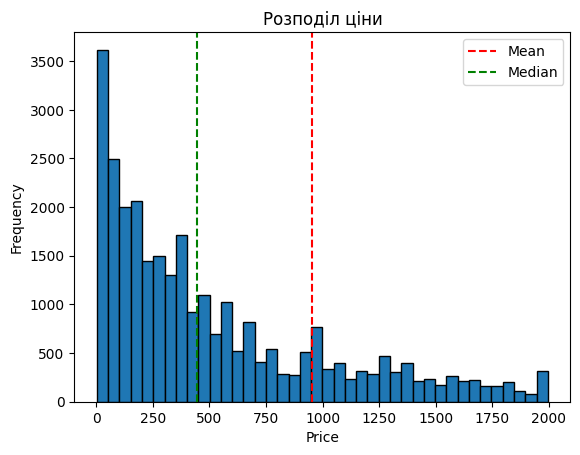

In [ ]:
plt.hist(df[df['price'] < 2000]['price'], bins=40, edgecolor='black')

plt.axvline(df['price'].mean(), color='red', linestyle='dashed', label='Mean')
plt.axvline(df['price'].median(), color='green', linestyle='dashed', label='Median')

plt.title('Розподіл ціни')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.legend()
plt.show()

*   Гістограма показує правосторонньо асиметричний розподіл цін: більшість товарів мають відносно низьку ціну, тоді як невелика кількість дорожчих товарів формує довгий правий хвіст. Середнє значення ціни помітно перевищує медіану, що також підтверджує наявність високих цінових значень, які зміщують розподіл вправо.

In [ ]:
avg_price_channel = (
    df.groupby('channel')['price']
    .mean()
    .sort_values(ascending=False)
)
avg_price_channel

,price
channel,
Undefined,971.588635
Direct,960.887615
Organic Search,959.076554
Paid Search,941.279518
Social Search,932.292231


In [ ]:
avg_price_category = (
    df.groupby('category')['price']
    .mean()
    .sort_values(ascending=False)
)
avg_price_category

,price
category,
Sofas & armchairs,1950.303302
Beds,1681.382433
Chairs,1032.887903
Cabinets & cupboards,1007.980802
Outdoor furniture,961.068730
"Sideboards, buffets & console tables",957.045455
Room dividers,820.800000
Bar furniture,673.537546
Chests of drawers & drawer units,624.354339


*   Середній чек за каналами майже не відрізняється і коливається в межах ~930–970, що свідчить про відсутність суттєвого впливу каналу залучення на вартість покупки. Натомість за категоріями спостерігається значна різниця: найдорожчими є Sofas & armchairs та Beds, тоді як найнижчий середній чек мають Children's furniture та Nursery furniture. Це може означати, що саме категорія товару, а не канал, є ключовим фактором, який визначає середню вартість замовлення

In [ ]:
avg_price_country = (
    df.groupby('country')['price']
    .mean()
    .sort_values(ascending=False)
)
avg_price_country

,price
country,
Palestine,1747.692308
Bulgaria,1518.111111
Albania,1401.500000
Venezuela,1396.769231
Kenya,1373.478261
...,...
Guatemala,322.714286
Luxembourg,293.000000
Costa Rica,277.076923


## **2.4 Data Analysis And Visualisation**

### **2.4.1 Sales by continent and country**

In [ ]:
# Top-3 continents by sales (price)
df.groupby('continent')['price'].sum().sort_values(ascending=False).head(3)

,price
continent,
Americas,17665280.0
Asia,7601298.3
Europe,5934624.2


In [ ]:
# Top-5 countries by sales (price)
df.groupby('country')['price'].sum().sort_values(ascending=False).head(5)

,price
country,
United States,13943553.9
India,2809762.0
Canada,2437921.0
United Kingdom,938317.9
France,710692.8


In [ ]:
sales_country = df.groupby('country')['price'].sum().reset_index()
sales_country

fig = px.choropleth(
    sales_country,
    locations='country',
    locationmode='country names',
    color='price',
    color_continuous_scale='Turbo',
    range_color=(0, 3000000),
    title='Sales by country'
)
fig.update_layout(
    title_x=0.5, # центрує заголовок
    width=1000,
    height=600
)
fig.show()

In [ ]:
# Top-3 continents by number of records
df['continent'].value_counts().nlargest(3)

,count
continent,
Americas,193179
Asia,83113
Europe,65135


country
France              6958
United Kingdom     11003
Canada             25994
India              32763
United States     153470
Name: count, dtype: int64


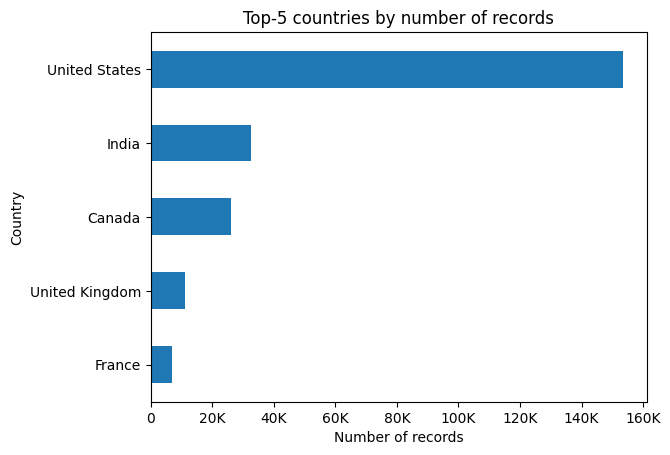

In [ ]:
# Функція форматування чисел на графіку
def format_k(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{int(x/1_000)}K'
    return str(int(x))

# Top-5 countries by number of records
top5 = df['country'].value_counts().nlargest(5).sort_values()
print(top5)
top5.plot(kind='barh')
plt.title('Top-5 countries by number of records')
plt.xlabel('Number of records')
plt.ylabel('Country')
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(format_k))
plt.show()

*   Найбільший обсяг продажів, як і кількість замовлень, припадає на Америку, далі йдуть Азія та Європа, що свідчить про домінування цих регіонів у структурі доходів компанії. Серед окремих країн лідером за продажами є США зі значним відривом, тоді як Індія, Канада, Велика Британія та Франція формують наступну групу ключових ринків.

### **2.4.2 Sales by category of products**

In [ ]:
# Top-10 categories by sales (price)
sales_category = df.groupby('category')['price'].sum().nlargest(10).sort_values() #sort_values(ascending=False).head(10)
sales_category

,price
category,
Children's furniture,467697.0
Bar furniture,735503.0
Chests of drawers & drawer units,906562.5
Tables & desks,1790307.5
Outdoor furniture,2142222.2
Cabinets & cupboards,2336499.5
Bookcases & shelving units,3640818.1
Beds,4919725.0
Chairs,6147748.8


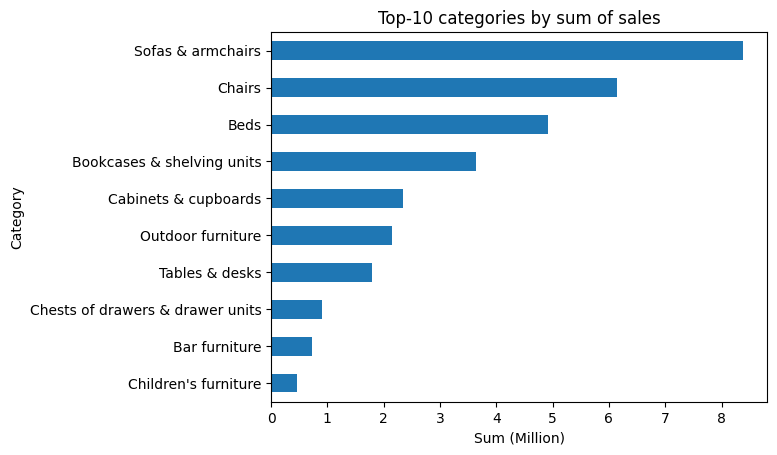

In [ ]:
(sales_category/1e6).sort_values().plot(kind='barh')
plt.title('Top-10 categories by sum of sales')
plt.xlabel('Sum (Million)')
plt.ylabel('Category')
plt.show()

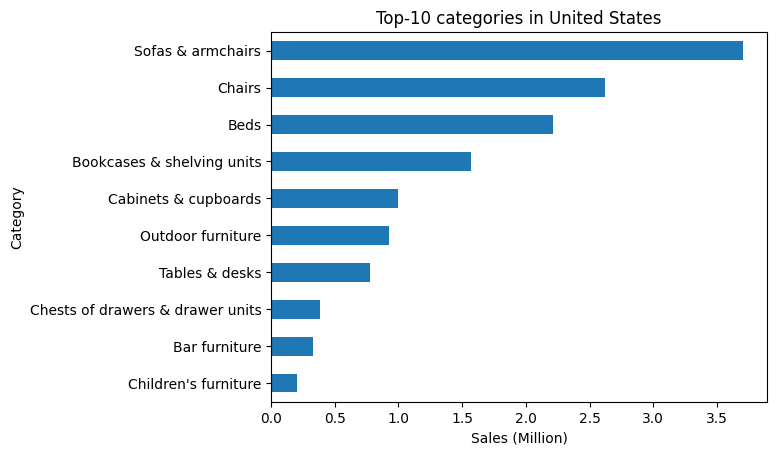

In [ ]:
top_country = df.groupby('country')['price'].sum().idxmax()

top_categories = (
    df[df['country'] == top_country]
    .groupby('category')['price']
    .sum()
    .nlargest(10)
    .sort_values()
    #.sort_values(ascending=False)
    #.head(10)
)

(top_categories/1e6).sort_values().plot(kind='barh')

plt.title(f'Top-10 categories in {top_country}')
plt.xlabel('Sales (Million)')
plt.ylabel('Category')

plt.show()

*   Найбільший обсяг продажів як загалом, так і в країні-лідері (United States) припадає на категорії Sofas & armchairs, Chairs та Beds, що свідчить про стабільно високий попит на ці товари. Отже, структура продажів у топ-країні практично не відрізняється від загальної картини, оскільки ті самі категорії залишаються лідерами за обсягом продажів.

### **2.4.3 Sales by device, mobile models and channels**

In [ ]:
# Total sales
total_sales = df['price'].sum()
print(f"Total sales: {total_sales:.2f}")

Total sales: 31971731.10


In [ ]:
# Share of sales by device in % from total sales
device_sales = (
    df.groupby('device')['price']
    .sum()
    .div(total_sales)
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

device_sales

,price
device,
desktop,59.00
mobile,38.73
tablet,2.26


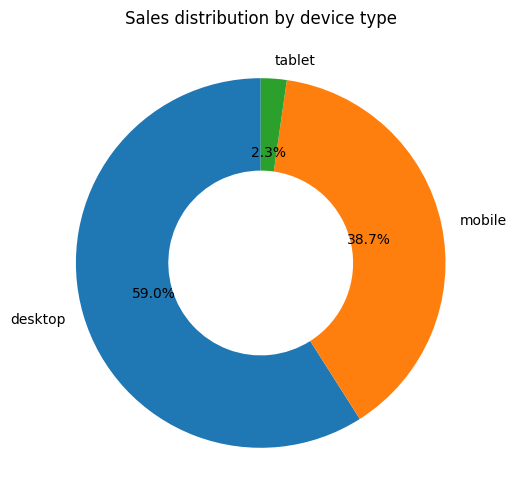

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    device_sales,
    labels=device_sales.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.5}  # створює "дірку" всередині
)

plt.title('Sales distribution by device type')

plt.show()

In [ ]:
mobile_model_analysis = df.groupby('mobile_model_name').agg(
    sales=('price','sum'),
    orders=('price','count')
)

mobile_model_analysis['sales_share_%'] = (
    mobile_model_analysis['sales'] / mobile_model_analysis['sales'].sum() * 100
).round(2)

mobile_model_analysis['orders_share_%'] = (
    mobile_model_analysis['orders'] / mobile_model_analysis['orders'].sum() * 100
).round(2)

mobile_model_analysis.sort_values('sales', ascending=False)


,sales,orders,sales_share_%,orders_share_%
mobile_model_name,,,,
Chrome,8899523.9,9359,27.84,27.91
<Other>,6535330.8,6801,20.44,20.28
Safari,6491062.1,6833,20.30,20.37
iPhone,6420776.3,6819,20.08,20.33
ChromeBook,1830458.7,1877,5.73,5.60
Edge,697222.3,741,2.18,2.21
iPad,448854.2,456,1.40,1.36
Firefox,421066.9,430,1.32,1.28
Pixel 4 XL,118287.7,117,0.37,0.35


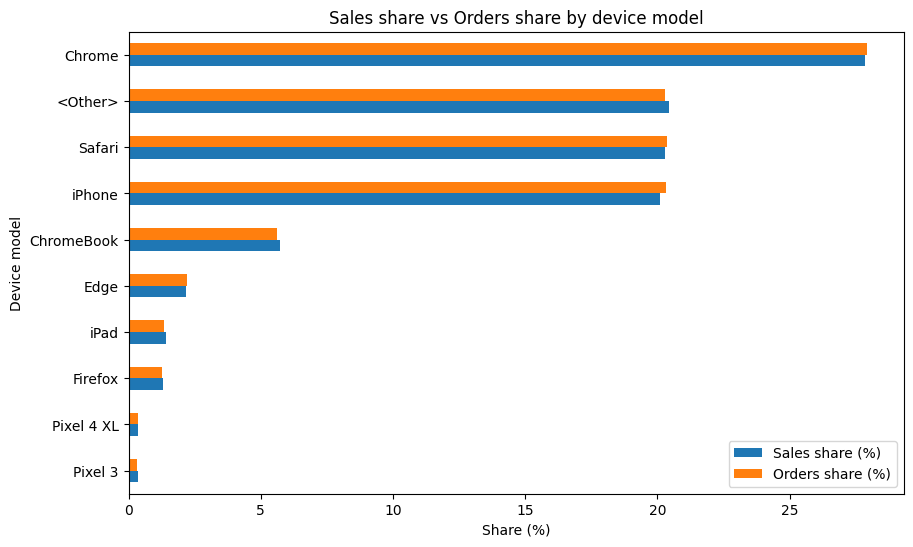

In [ ]:
mobile_model_analysis.sort_values('sales_share_%')[['sales_share_%','orders_share_%']].plot(kind='barh', figsize=(10,6))
plt.title('Sales share vs Orders share by device model')
plt.xlabel('Share (%)')
plt.ylabel('Device model')

plt.legend(['Sales share (%)', 'Orders share (%)'])

plt.show()

*   Найбільша частка продажів припадає на desktop-пристрої (близько 59%), тоді як mobile генерує близько 39%, а tablet має незначну частку (~2%). Серед моделей девайсів лідирує Chrome, а також значну частку продажів і замовлень забезпечують Safari та iPhone, причому частки продажів і замовлень для більшості моделей майже збігаються, що свідчить про пропорційний внесок цих пристроїв у загальний обсяг продажів.

In [ ]:
# Share of sales by channel in % from total sales
channel_sales = (
    df.groupby('channel')['price']
    .sum()
    .div(total_sales)
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

channel_sales

,price
channel,
Organic Search,35.76
Paid Search,26.62
Direct,23.44
Social Search,7.92
Undefined,6.26


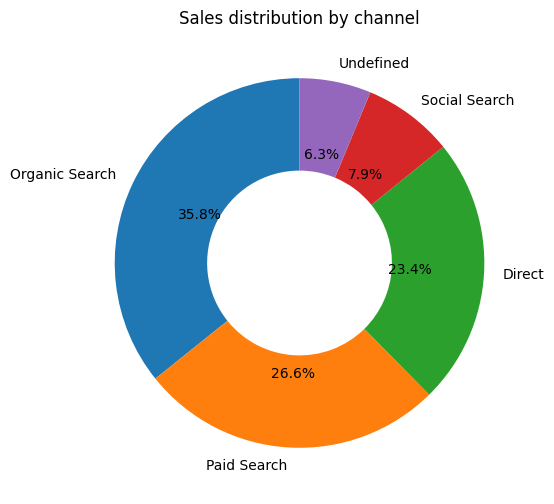

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    channel_sales,
    labels=channel_sales.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.5}  # створює "дірку" всередині
)

plt.title('Sales distribution by channel')

plt.show()

### **2.4.4 Analisis of registered users**

In [ ]:
# Filter rows where account_id is not missing (only registered users)
registered_users = df[df['account_id'].notna()]

# Count how many registered users are verified (sum of True values, 1 - is verified, 0 - is not verified )
verified = registered_users['is_verified'].sum()

# Count the total number of registered users with a verification status
total = registered_users['is_verified'].count()

# Count how many registered users have unsubscribed (sum of True values, 0 – active subscribers, 1 – unsubscribed)
unsubscribed = registered_users['is_unsubscribed'].sum()

print(f"Total registrated users: {total}")
print(f"Verified registrated users: {verified}")
print(f"{verified} of {total} users verified email ({verified/total*100:.2f}%)")
print(f"Unsubscribed registrated users: {unsubscribed}")
print(f"Subscribed registrated users: {total-unsubscribed}")
print(f"{unsubscribed} users unsubscribed of {total} total registrated users ({unsubscribed/total*100:.2f}%)")


Total registrated users: 27945
Verified registrated users: 20036
20036 of 27945 users verified email (71.70%)
Unsubscribed registrated users: 4735
Subscribed registrated users: 23210
4735 users unsubscribed of 27945 total registrated users (16.94%)


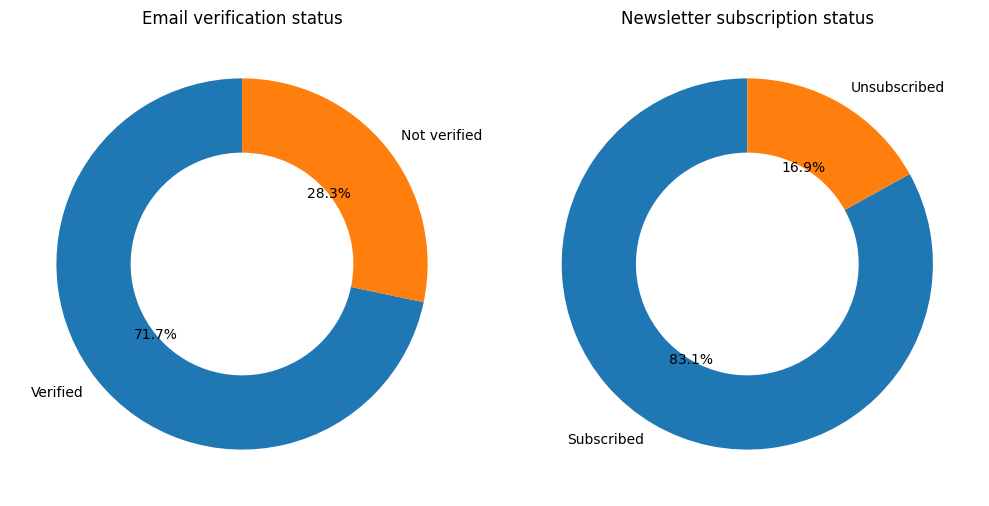

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# Email verification
axes[0].pie(
    [verified, total-verified],
    labels=['Verified', 'Not verified'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)
axes[0].set_title('Email verification status')

# Newsletter subscription
axes[1].pie(
    [total-unsubscribed, unsubscribed],
    labels=['Subscribed', 'Unsubscribed'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)
axes[1].set_title('Newsletter subscription status')

plt.tight_layout()
plt.show()

In [ ]:
pd.crosstab(df['is_verified'], df['is_unsubscribed'])

is_unsubscribed,0,1
is_verified,,
0,7478,431
1,15732,4304


In [ ]:
buyers_analysis = registered_users.groupby('is_unsubscribed').agg(
    users=('account_id','nunique'),
    buyers=('account_id', lambda x: x[registered_users.loc[x.index,'price']>0].nunique())
)

buyers_analysis['conversion_%'] = (buyers_analysis['buyers'] /
                                   buyers_analysis['users'] * 100).round(2)

buyers_analysis

,users,buyers,conversion_%
is_unsubscribed,,,
0,23210,2334,10.06
1,4735,447,9.44


*   Більшість зареєстрованих користувачів підтвердили свою електронну адресу (71,7%), тоді як 16,9% користувачів відписалися від розсилки, що свідчить про загалом високий рівень залученості аудиторії.
*   Аналіз поведінки показує, що конверсія у покупку серед підписаних користувачів (10,06%) дещо вища, ніж серед тих, хто відписався (9,44%), що може свідчити про позитивний вплив підписки на розсилку на ймовірність здійснення покупки.

In [ ]:
# Total sales
print(f"Total sales: {total_sales:.2f}")
# Sales generated by each group (0 – active subscribers, 1 – unsubscribed)
sales_by_unsubscribe = df.groupby('is_unsubscribed')['price'].sum().reset_index()
sales_by_unsubscribe['sales_share_%'] = (sales_by_unsubscribe['price'] / total_sales * 100).round(2)
sales_by_unsubscribe

Total sales: 31971731.10


,is_unsubscribed,price,sales_share_%
0,0,2150796.9,6.73
1,1,431721.6,1.35


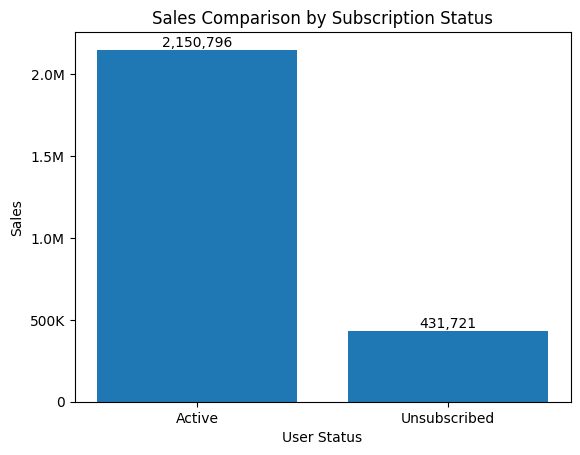

In [ ]:
labels = ['Active', 'Unsubscribed']
values = sales_by_unsubscribe['price']

plt.figure()

bars = plt.bar(labels, values)

# Додавання підписів над стовпчиками
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',  # ← формат з комами
        ha='center',
        va='bottom'
    )

plt.ticklabel_format(style='plain', axis='y')

plt.xlabel('User Status')
plt.ylabel('Sales')
plt.title('Sales Comparison by Subscription Status')

plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(format_k))
plt.show()

*   Основну частку продажів формують активні користувачі (понад 2,1 млн), тоді як користувачі, що відписалися, генерують значно менше (близько 0,43 млн). Це може свідчити про суттєвий вплив активної підписки на обсяг продажів і важливість утримання користувачів.

In [ ]:
# Count a number of registered users by country
users_by_country = (
    registered_users
    .groupby('country')['account_id']
    .count()
    .sort_values(ascending=False)
)

#Top-10 countries by a number of regirested users
users_by_country = users_by_country.reset_index(name='users_count')
users_by_country.head(10)

,country,users_count
0,United States,12384
1,India,2687
2,Canada,2067
3,United Kingdom,859
4,France,553
5,Spain,536
6,Taiwan,500
7,China,490
8,Germany,490
9,Italy,386


In [ ]:
# Count a number of registered users by device
users_by_device = (
    registered_users
    .groupby('device')['account_id']
    .count()
    .sort_values(ascending=False)
)

#Top-10 countries by a number of regirested users
users_by_device = users_by_device.reset_index(name='users_count')
users_by_device

,device,users_count
0,desktop,16417
1,mobile,10878
2,tablet,650


In [ ]:
# Count a number of registered users by browser
users_by_browser = (
    registered_users
    .groupby('browser')['account_id']
    .count()
    .sort_values(ascending=False)
)
users_by_browser = users_by_browser.reset_index(name='users_count')
users_by_browser

,browser,users_count
0,Chrome,19087
1,Safari,6595
2,<Other>,730
3,Edge,673
4,Firefox,490
5,Android Webview,370


In [ ]:
# Count a number of registered users by language
users_by_language = (
    registered_users
    .groupby('language')['account_id']
    .count()
    .sort_values(ascending=False)
)
users_by_language = users_by_language.reset_index(name='users_count')
users_by_language

,language,users_count
0,en-us,12770
1,en-gb,1978
2,zh,958
3,en,887
4,en-ca,783
5,fr,462
6,es-es,442
7,de,247
8,ko,217


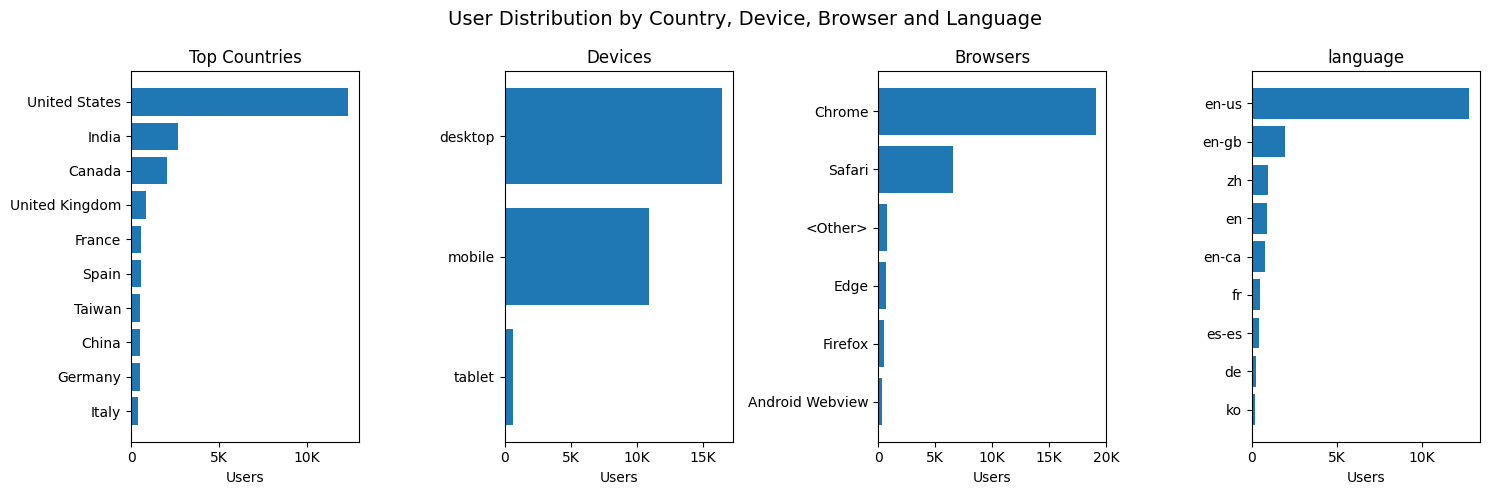

In [ ]:
# Створюємо 3 графіки в одному рядку
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
fig.suptitle('User Distribution by Country, Device, Browser and Language', fontsize=14)

# 1. Countries (top-10)
top10_countries = users_by_country.head(10)
axes[0].barh(top10_countries['country'], top10_countries['users_count'])
axes[0].invert_yaxis()
axes[0].set_title('Top Countries')
axes[0].set_xlabel('Users')

# 2. Devices
axes[1].barh(users_by_device['device'], users_by_device['users_count'])
axes[1].invert_yaxis()
axes[1].set_title('Devices')
axes[1].set_xlabel('Users')

# 3. Browsers
axes[2].barh(users_by_browser['browser'], users_by_browser['users_count'])
axes[2].invert_yaxis()
axes[2].set_title('Browsers')
axes[2].set_xlabel('Users')

# 4. Language
axes[3].barh(users_by_language['language'], users_by_language['users_count'])
axes[3].invert_yaxis()
axes[3].set_title('language')
axes[3].set_xlabel('Users')

# Застосування функції форматування чисел
for ax in axes:
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(format_k))

plt.tight_layout()
plt.show()

*   Найбільша кількість зареєстрованих користувачів припадає на США, при цьому основний трафік формується з десктопних пристроїв і браузера Chrome. Домінує англомовна аудиторія (en-us), що вказує на концентрацію користувачів у англомовних країнах.

## **2.5 Analysis of sales dynamics**

### **2.5.1 Overall sales dynamics by days**


In [ ]:
sales_by_date = (
    df.groupby('date')['price']
    .sum()
    .reset_index()
)
sales_by_date.head()


,date,price
0,2020-11-01,244292.5
1,2020-11-02,355506.8
2,2020-11-03,498979.6
3,2020-11-04,339187.1
4,2020-11-05,391276.6


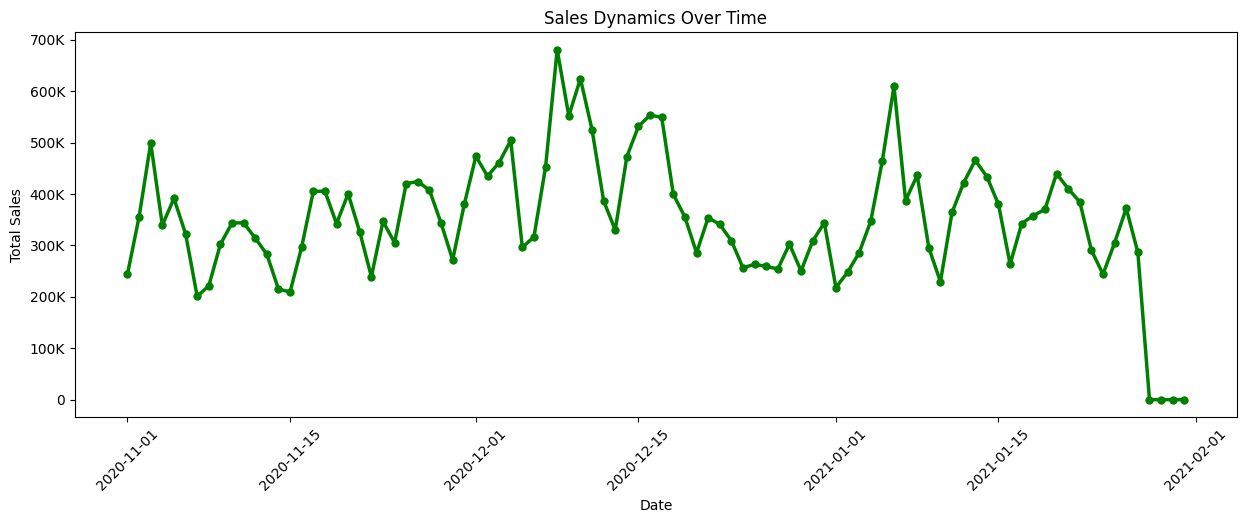

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    sales_by_date['date'],
    sales_by_date['price'],
    color='green',
    linewidth=2.5,
    marker='o',
    markersize=5
)

plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Sales Dynamics Over Time')

plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(format_k))
plt.show()

*   Протягом всього періоду часу продажі демонструють коливання з окремими піками (зокрема на початку грудня та січня), однак чітко вираженої регулярної сезонності не простежується. Наприкінці періоду спостерігається різке падіння до нуля, що, ймовірно, пов’язано з неповнотою даних, а не реальною динамікою.

### **2.5.2 Sales Dynamics by Continent**

In [ ]:
sales_dynamics_by_continent = (
    df.groupby(['date', 'continent'])['price']
    .sum()
    .reset_index()
)

In [ ]:
filtered_data = sales_dynamics_by_continent[
    sales_dynamics_by_continent['continent'].isin(['Americas', 'Asia', 'Europe'])
]

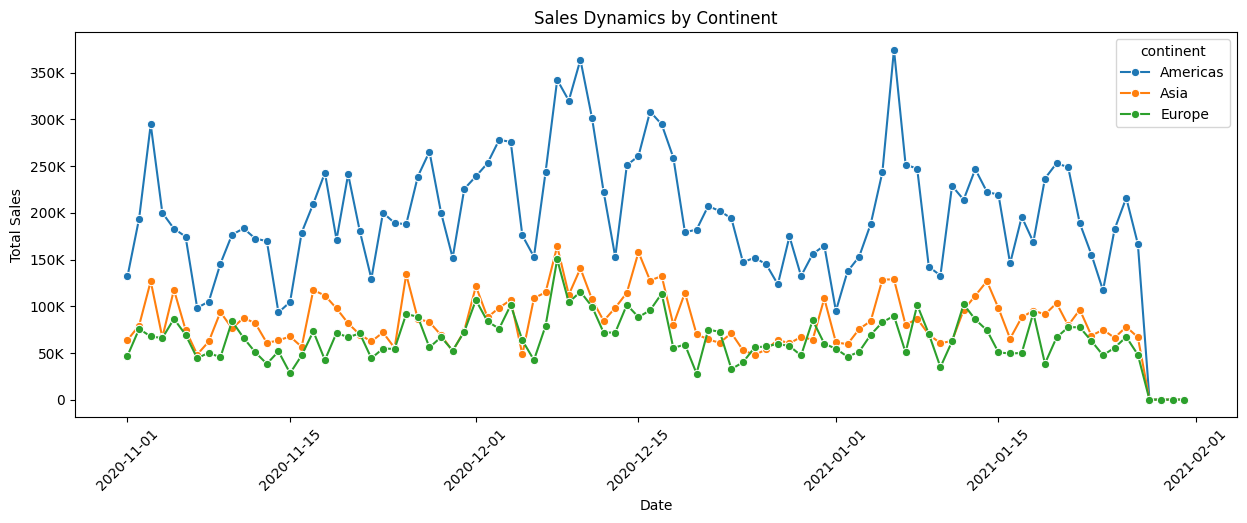

In [ ]:
plt.figure(figsize=(15, 5))

sns.lineplot(
    data=filtered_data,
    x='date',
    y='price',
    hue='continent',   # різні континенти = різні кольори
    marker='o'
)

plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Sales Dynamics by Continent')

plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(format_k))
plt.show()

*   Продажі в усіх трьох континентах коливаються з подібною динамікою, при цьому Америка стабільно лідирує за обсягами

### **2.5.3 Sales Dynamics by Channel**

In [ ]:
sales_dynamics_by_channel = (
    df.groupby(['date', 'channel'])['price']
    .sum()
    .reset_index()
)

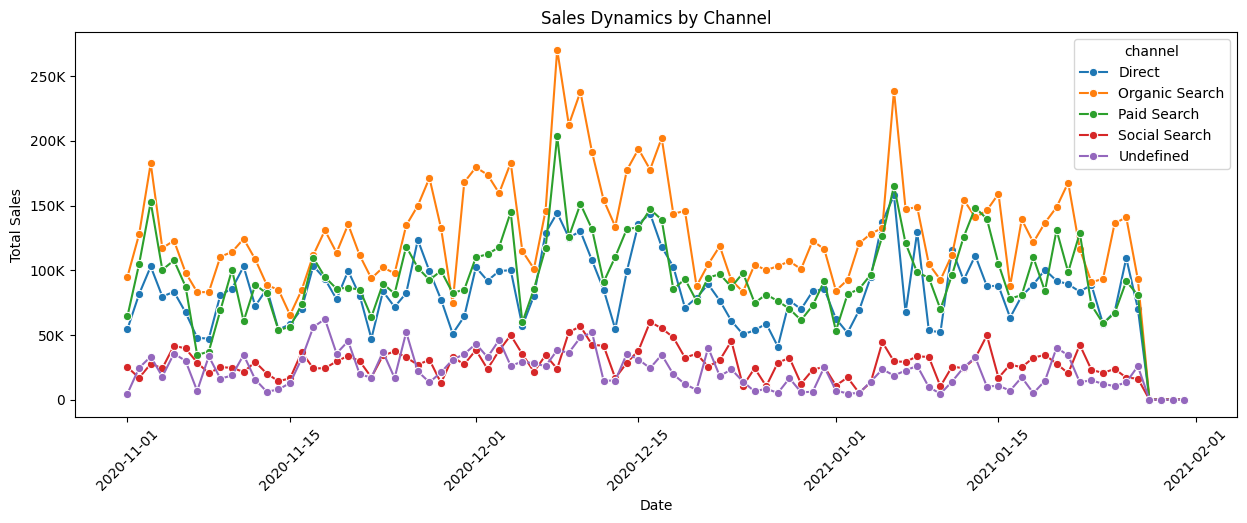

In [ ]:
plt.figure(figsize=(15, 5))

sns.lineplot(
    data=sales_dynamics_by_channel,
    x='date',
    y='price',
    hue='channel',   # різні канали трафіку = різні кольори
    marker='o'
)

plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Sales Dynamics by Channel')

plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(format_k))
plt.show()

*   Найбільші обсяги продажів стабільно генерує канал Organic Search, за ним слідують Paid Search і Direct, тоді як Social Search та Undefined мають значно менший внесок. Динаміка каналів досить подібна з періодичними піками.

### **2.5.4 Sales Dynamics by Device**

In [ ]:
sales_dynamics_by_device = (
    df.groupby(['date', 'device'])['price']
    .sum()
    .reset_index()
)

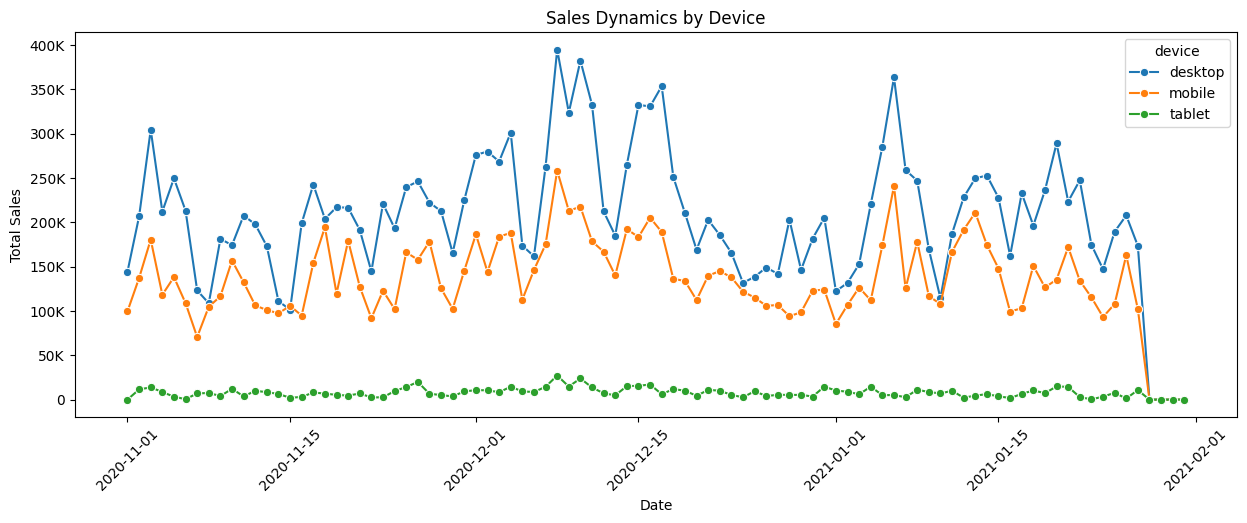

In [ ]:
plt.figure(figsize=(15, 5))

sns.lineplot(
    data=sales_dynamics_by_device,
    x='date',
    y='price',
    hue='device',   # різні канали трафіку = різні кольори
    marker='o'
)

plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Sales Dynamics by Device')

plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(format_k))
plt.show()

*   Продажі переважно генеруються з десктопних пристроїв, які стабільно демонструють найвищі значення, тоді як mobile має середній рівень внеску, а tablet — мінімальний. Динаміка для всіх пристроїв є схожою з періодичними піками, а наприкінці періоду спостерігається різке падіння, ймовірно через неповні дані.

## **2.6 Pivot Tables**

### **2.6.1 Pivot Table of Sessions in Veiw of Channels and Devices**

In [ ]:
# Count number of session in veiw of channels and devices
pivot_table = (
    df.dropna(subset=['channel', 'device', 'ga_session_id'])
      .groupby(['channel', 'device'])['ga_session_id']
      .count()
      .unstack(fill_value=0)
)
# Sort by total sum in row
pivot_table['total'] = pivot_table.sum(axis=1)
pivot_table_session_channel_device = pivot_table.sort_values('total', ascending=False)
pivot_table_session_channel_device

device,desktop,mobile,tablet,total
channel,,,,
Organic Search,72622,49014,2789,124425
Paid Search,55167,37034,2140,94341
Direct,47825,31745,1812,81382
Social Search,16288,10988,638,27914
Undefined,12527,8486,470,21483


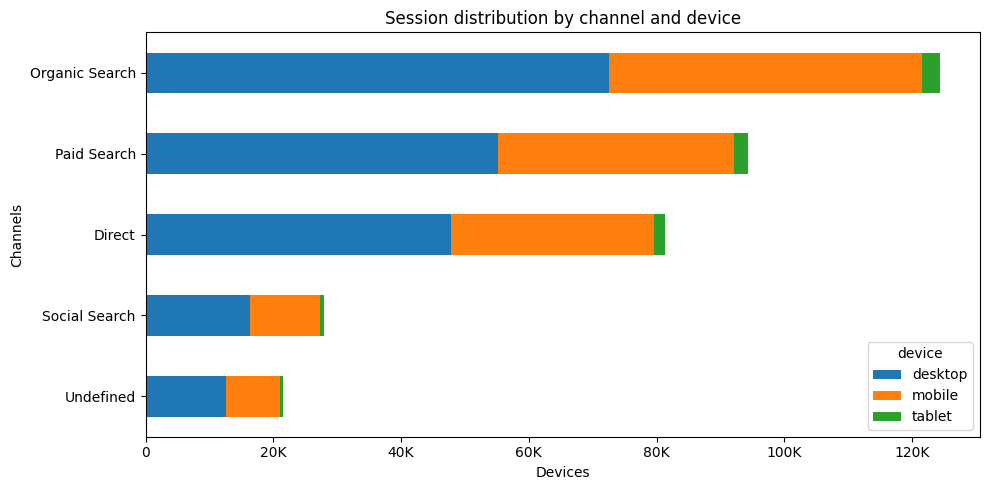

In [ ]:
df_devices = pivot_table_session_channel_device[['desktop', 'mobile', 'tablet']]
df_devices_plot = df_devices.iloc[::-1]

ax = df_devices_plot.plot(kind='barh', stacked=True, figsize=(10, 5))

ax.set_title('Session distribution by channel and device')
ax.set_xlabel('Devices')
ax.set_ylabel('Channels')

ax.xaxis.set_major_formatter(mtick.FuncFormatter(format_k))

plt.tight_layout()
plt.show()

In [ ]:
# Count share of a device in total of channel
df_devices = pivot_table_session_channel_device[['desktop', 'mobile', 'tablet']]
share = (df_devices.div(df_devices.sum(axis=1), axis=0) * 100 ).round(2)
share

device,desktop,mobile,tablet
channel,,,
Organic Search,58.37,39.39,2.24
Paid Search,58.48,39.26,2.27
Direct,58.77,39.01,2.23
Social Search,58.35,39.36,2.29
Undefined,58.31,39.5,2.19


*   Основний обсяг трафіку генерується каналами Organic Search, Paid Search та Direct, при цьому найбільший внесок має органічний пошук. У всіх каналах спостерігається майже однакова структура девайсів: домінує desktop (близько 58%), далі mobile (близько 39%), а tablet має незначну частку (близько 2%). Це свідчить про стабільну поведінку користувачів незалежно від джерела трафіку.

### **2.6.2 Pivot Table of Sales in Veiw of Categories and Countries**

In [ ]:
# Count total sales by categories (top-10) and countries (top-5)

# 1. Прибираємо рядки з пропущеними значеннями
df_sales = df.dropna(subset=['category', 'country', 'price'])

# 2. Знаходимо топ-10 категорій за сумою продажів
top_categories = (
    df_sales.groupby('category')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# 3. Знаходимо топ-5 країн за сумою продажів
top_countries = (
    df_sales.groupby('country')['price']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# 4. Фільтруємо дані
df_top = df_sales[
    df_sales['category'].isin(top_categories) &
    df_sales['country'].isin(top_countries)
]

# 5. Створюємо зведену таблицю
pivot_table_sales_category_country = (
    df_top.groupby(['category', 'country'])['price']
    .sum()
    .unstack(fill_value=0)
)

# 6. Сортуємо рядки за загальною сумою продажів
pivot_table_sales_category_country['total'] = pivot_table_sales_category_country.sum(axis=1)
pivot_table_sales_category_country = pivot_table_sales_category_country.sort_values('total', ascending=False)

# 7. Сортуємо стовпці-країни за загальною сумою продажів
country_order = (
    pivot_table_sales_category_country.drop(columns='total')
    .sum(axis=0)
    .sort_values(ascending=False)
    .index
)

pivot_table_sales_category_country = pivot_table_sales_category_country[list(country_order) + ['total']]

pivot_table_sales_category_country

country,United States,India,Canada,United Kingdom,France,total
category,,,,,,
Sofas & armchairs,3707144.5,788430.0,692427.5,234812.0,187735.0,5610549.0
Chairs,2619773.8,544309.2,417740.8,188519.4,134029.4,3904372.6
Beds,2213058.0,358319.5,354772.0,133816.0,116414.0,3176379.5
Bookcases & shelving units,1567606.9,364507.4,278981.9,113987.6,73830.0,2398913.8
Cabinets & cupboards,994545.5,191888.0,181802.0,71684.5,59101.5,1499021.5
Outdoor furniture,929245.2,162289.4,185322.8,57002.4,40486.4,1374346.2
Tables & desks,777865.0,186157.5,132678.0,49374.0,42299.0,1188373.5
Chests of drawers & drawer units,382388.0,73111.0,71952.0,36784.0,21544.5,585779.5
Bar furniture,330805.0,57657.0,51724.0,22103.0,11199.0,473488.0


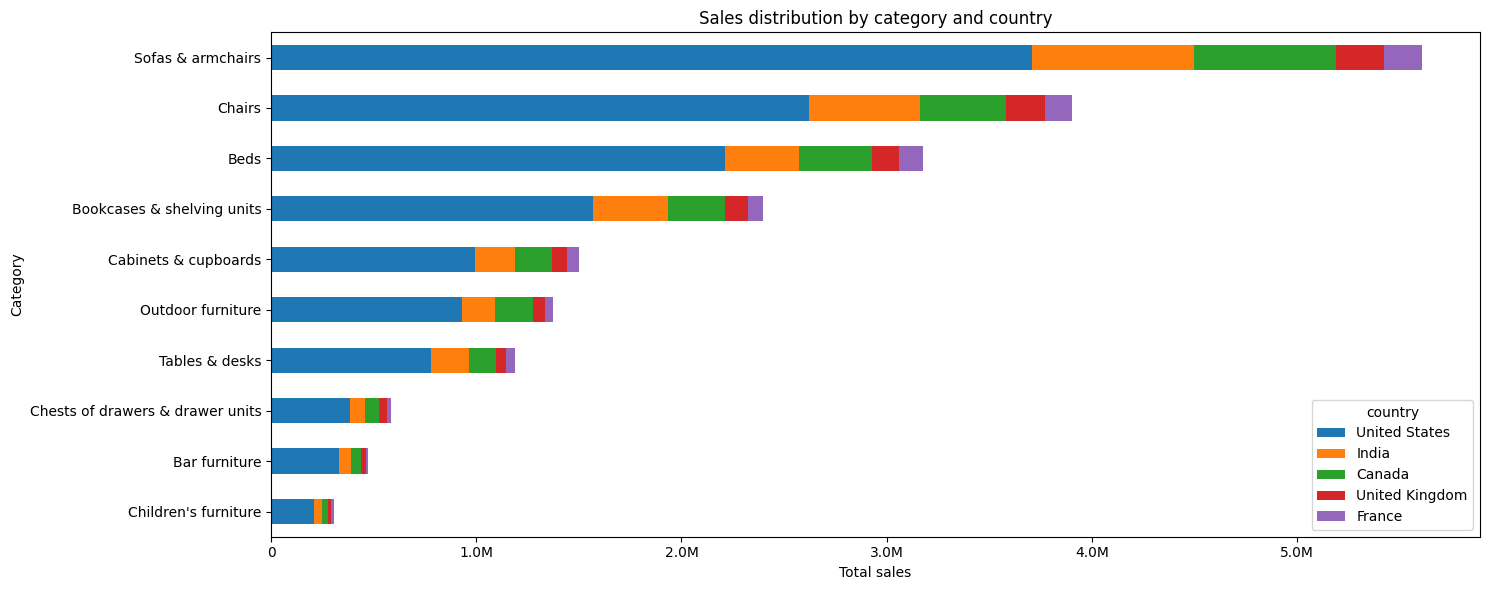

In [ ]:
ax = pivot_table_sales_category_country.drop(columns='total').iloc[::-1] \
    .plot(kind='barh', stacked=True, figsize=(15, 6))

plt.title('Sales distribution by category and country')
plt.xlabel('Total sales')
plt.ylabel('Category')

ax.xaxis.set_major_formatter(mtick.FuncFormatter(format_k))

plt.tight_layout()
plt.show()

In [ ]:
share_country_category = (
    pivot_table_sales_category_country.drop(columns='total')
    .div(pivot_table_sales_category_country.drop(columns='total').sum(axis=1), axis=0)
    * 100
).round(2)

share_country_category

country,United States,India,Canada,United Kingdom,France
category,,,,,
Sofas & armchairs,66.07,14.05,12.34,4.19,3.35
Chairs,67.10,13.94,10.70,4.83,3.43
Beds,69.67,11.28,11.17,4.21,3.66
Bookcases & shelving units,65.35,15.19,11.63,4.75,3.08
Cabinets & cupboards,66.35,12.80,12.13,4.78,3.94
Outdoor furniture,67.61,11.81,13.48,4.15,2.95
Tables & desks,65.46,15.66,11.16,4.15,3.56
Chests of drawers & drawer units,65.28,12.48,12.28,6.28,3.68
Bar furniture,69.87,12.18,10.92,4.67,2.37


*   Найбільший обсяг продажів спостерігається в категорії Sofas & armchairs, далі йдуть Chairs та Beds, причому в усіх категоріях домінує ринок United States. Частка США стабільно становить близько 65–70%, тоді як India і Canada займають друге місце з помітно меншими, але відносно близькими частками (~10–15%). Інші країни (United Kingdom та France) мають незначний внесок (до ~5%), що свідчить про сильну концентрацію продажів на одному ключовому ринку.

In [ ]:
# Count total sales by channel and countries (top-5)
pivot_table_sales_channel_country = (
    df[df['country'].isin(top_countries)]
      .dropna(subset=['channel', 'country', 'price'])
      .groupby(['channel', 'country'])['price']
      .sum()
      .unstack(fill_value=0)
      .assign(total=lambda x: x.sum(axis=1))
      .sort_values('total', ascending=False)
      .drop(columns='total')
      .loc[:, lambda x: x.sum(axis=0).sort_values(ascending=False).index]
)
pivot_table_sales_channel_country

country,United States,India,Canada,United Kingdom,France
channel,,,,,
Organic Search,4958993.0,972575.7,873719.7,356438.9,261008.6
Paid Search,3589463.4,729970.0,674902.0,278652.6,192421.3
Direct,3346860.3,700256.0,609806.3,203728.9,169299.5
Social Search,1132651.1,215703.8,151244.2,51836.0,46713.4
Undefined,915586.1,191256.5,128248.8,47661.5,41250.0


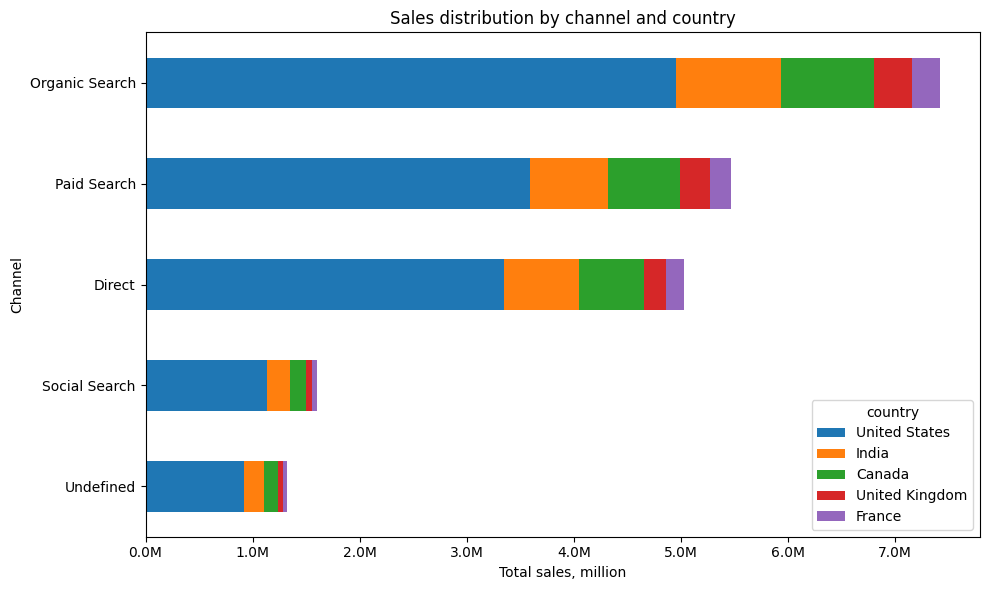

In [ ]:
df_plot = pivot_table_sales_channel_country.iloc[::-1]

ax = df_plot.plot(kind='barh', stacked=True, figsize=(10, 6))

plt.title('Sales distribution by channel and country')
plt.xlabel('Total sales, million')
plt.ylabel('Channel')
ax.xaxis.set_major_formatter(
     mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

plt.tight_layout()
plt.show()

*   Основний обсяг продажів генерується каналом Organic Search, далі йдуть Paid Search та Direct, що свідчить про ключову роль пошукових каналів у формуванні доходу. У всіх каналах домінує ринок United States, тоді як інші країни роблять значно менший внесок, формуючи подібну структуру продажів незалежно від джерела трафіку.

# **3. Statistical analysis of relationships**

## **3.1 Daily Sessions and Total Sales Correlation**

In [ ]:
# Daily Sessions and Total Sales Aggregation
daily_stats = df.groupby('date').agg(
    sessions=('ga_session_id', 'nunique'),  # кількість унікальних сесій
    total_sales=('price', 'sum')            # загальні продажі
).reset_index()

daily_stats.head()

,date,sessions,total_sales
0,2020-11-01,2576,244292.5
1,2020-11-02,3599,355506.8
2,2020-11-03,5173,498979.6
3,2020-11-04,4184,339187.1
4,2020-11-05,3743,391276.6


In [ ]:
# Daily Sessions and Total Sales Correlation
daily_stats[['sessions', 'total_sales']].corr()

,sessions,total_sales
sessions,1.000000,0.791081
total_sales,0.791081,1.000000


In [ ]:
r = 0.791081 # Коефіцієнт кореляції

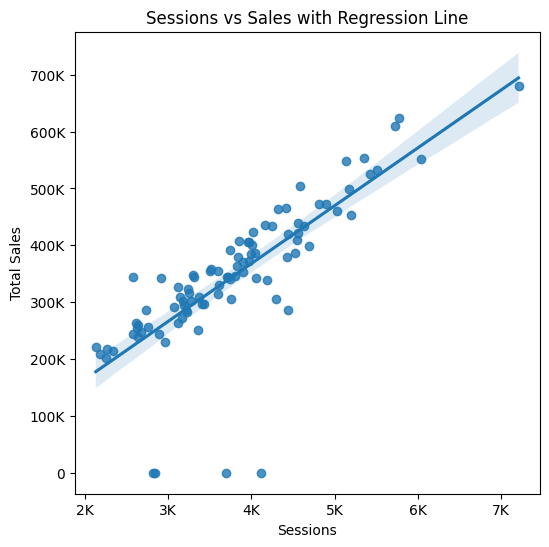

In [ ]:
plt.figure(figsize=(6,6))

sns.regplot(
    data=daily_stats,
    x='sessions',
    y='total_sales'
)

plt.xlabel('Sessions')
plt.ylabel('Total Sales')
plt.title('Sessions vs Sales with Regression Line')

plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(format_k))
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(format_k))

plt.show()

*   Між щоденною кількістю сесій та продажами одержали коефіцієнт кореляції r ≈ 0.79, що свідчить про позитивну кореляцію між цими показниками. Лінійний зв'язок між цими покахниками також бачимо на діаграмі розсіювання, тобто, чим більша кількість сесій, тим більша сума продажів.

In [ ]:
# Calculate Statistical Significance (p-value) (check whether this relationship is not due to random chance)
r, p_value = pearsonr(daily_stats['sessions'], daily_stats['total_sales'])

print(f"Correlation: {r:.3f}")
print(f"P-value: {p_value:.5f}")

Correlation: 0.791
P-value: 0.00000


*   There is a strong positive correlation between sessions and total sales (r = 0.791), indicating that higher traffic is associated with increased sales. The p-value is effectively zero (p < 0.05), confirming that this relationship is statistically significant and not due to random chance.
*   Існує сильна позитивна кореляція між кількістю сесій та загальними продажами (r = 0.791), що свідчить про те, що зі зростанням трафіку зростають і продажі. Значення p-value практично дорівнює нулю (тобто задовольняє умову p < 0.05), що підтверджує статистичну значущість цього зв’язку і його невипадковий характер.

## **3.2 Correlation Analysis of Top-3 Continents by Daily Sales**

In [ ]:
top_continents = (
    df.groupby('continent')['price']
    .sum()
    .nlargest(3)
    .index
)
top_continents

Index(['Americas', 'Asia', 'Europe'], dtype='object', name='continent')

In [ ]:
# Aggregation sales accross continent by date
continent_daily = (
    df[df['continent'].isin(top_continents)]
    .groupby(['date', 'continent'])['price']
    .sum()
    .unstack()
)

continent_daily.head()

continent,Americas,Asia,Europe
date,,,
2020-11-01,132002.5,63823.0,46908.0
2020-11-02,193861.0,79370.0,75710.8
2020-11-03,294529.8,126737.8,67692.0
2020-11-04,200009.5,66602.0,65915.0
2020-11-05,182988.2,117608.4,86540.0


In [ ]:
# Correlation matrix
continent_corr = continent_daily.corr()
continent_corr

continent,Americas,Asia,Europe
continent,,,
Americas,1.000000,0.792025,0.770586
Asia,0.792025,1.000000,0.768427
Europe,0.770586,0.768427,1.000000


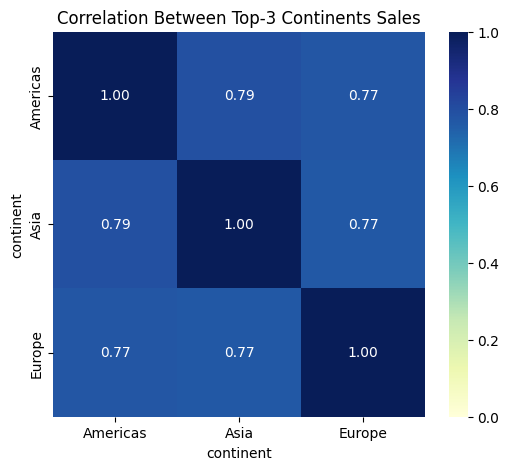

In [ ]:
# Visualization of the correlation matrix as a heatmap
plt.figure(figsize=(6,5))
sns.heatmap(continent_corr, annot=True, fmt=".2f", cmap='YlGnBu', vmin=0, vmax=1)
plt.title('Correlation Between Top-3 Continents Sales')
plt.show()

In [ ]:

r_amas, p_amas = pearsonr(continent_daily['Americas'], continent_daily['Asia'])
r_ameu, p_ameu = pearsonr(continent_daily['Americas'], continent_daily['Europe'])
r_aseu, p_aseu = pearsonr(continent_daily['Asia'], continent_daily['Europe'])

print(f"Americas vs Asia     r = {r_amas:.3f}, p = {p_amas:.3f}")
print(f"Americas vs Europe   r = {r_ameu:.3f}, p = {p_ameu:.3f}")
print(f"Asia vs Europe       r = {r_aseu:.3f}, p = {p_aseu:.3f}")

Americas vs Asia     r = 0.792, p = 0.000
Americas vs Europe   r = 0.771, p = 0.000
Asia vs Europe       r = 0.768, p = 0.000


*   Продажі між трьома основними континентами (Americas, Asia, Europe) демонструють сильну позитивну кореляцію  (r ≈ 0.77–0.79), що свідчить про подібну динаміку змін у часі. Це може вказувати на вплив глобальних факторів, таких як сезонність або маркетингові кампанії. Такий рівень кореляції означає, що ринки розвиваються синхронно, хоча не є повністю ідентичними.
*   Усі отримані значення p-value є значно меншими за 0.05, що свідчить про статистичну значущість виявлених кореляцій. Отже, спостережувані взаємозв’язки між продажами на континентах не є випадковими і мають надійний характер.

## **3.3 Correlation Analysis of Channels by Daily Sales**

In [ ]:
# Aggregation of sales by dates and channels
channel_daily = (
    df.groupby(['date', 'channel'])['price']
    .sum()
    .unstack()
)
channel_daily.head()

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
date,,,,,
2020-11-01,54669.5,95112.0,64688.0,25078.0,4745.0
2020-11-02,81561.5,127746.5,104780.8,16843.0,24575.0
2020-11-03,102909.5,182521.9,152641.3,27652.5,33254.4
2020-11-04,79683.6,117067.1,100332.0,24257.4,17847.0
2020-11-05,83367.6,122938.4,107648.0,41693.2,35629.4


In [ ]:
# Correlation matrix
channel_corr = channel_daily.corr().round(3)
channel_corr

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
channel,,,,,
Direct,1.000,0.838,0.814,0.604,0.518
Organic Search,0.838,1.000,0.870,0.583,0.526
Paid Search,0.814,0.870,1.000,0.596,0.522
Social Search,0.604,0.583,0.596,1.000,0.455
Undefined,0.518,0.526,0.522,0.455,1.000


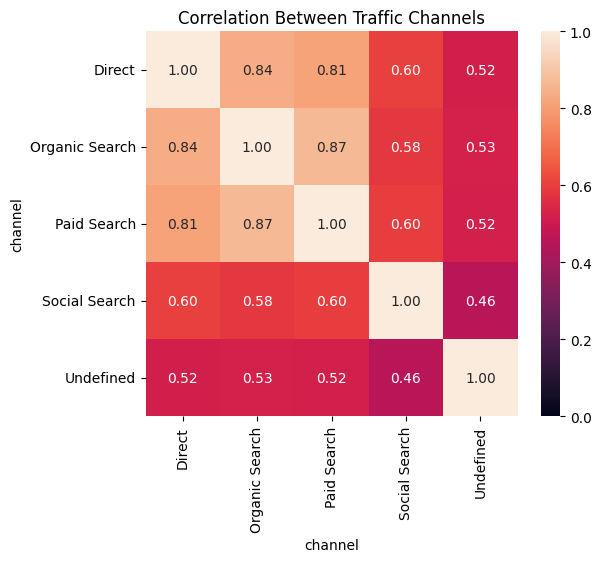

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(channel_corr, annot=True, fmt=".2f", vmin=0, vmax=1)
plt.title('Correlation Between Traffic Channels')
plt.show()

In [ ]:
# Correlation and p-values between channels
from itertools import combinations

for ch1, ch2 in combinations(channel_daily.columns, 2):
    temp = channel_daily[[ch1, ch2]].dropna()
    r, p = pearsonr(temp[ch1], temp[ch2])

    print(f"{ch1} vs {ch2}  r = {r:.3f}, p = {p:.3f}")

Direct vs Organic Search  r = 0.838, p = 0.000
Direct vs Paid Search  r = 0.814, p = 0.000
Direct vs Social Search  r = 0.604, p = 0.000
Direct vs Undefined  r = 0.518, p = 0.000
Organic Search vs Paid Search  r = 0.870, p = 0.000
Organic Search vs Social Search  r = 0.583, p = 0.000
Organic Search vs Undefined  r = 0.526, p = 0.000
Paid Search vs Social Search  r = 0.596, p = 0.000
Paid Search vs Undefined  r = 0.522, p = 0.000
Social Search vs Undefined  r = 0.455, p = 0.000


*   Продажі між основними каналами трафіку демонструють помірну та сильну позитивну кореляцію (r ≈ 0.58–0.87), причому найсильніший зв’язок спостерігається між Organic Search і Paid Search, а також між Direct і Organic Search. Це свідчить про узгоджену динаміку змін продажів і можливий вплив спільних факторів, таких як сезонність або загальний попит.

*   Усі отримані значення p-value є значно меншими за 0.05, що підтверджує статистичну значущість виявлених взаємозв’язків. Отже, кореляції між каналами не є випадковими і відображають реальні закономірності у поведінці продажів.

## **3.4 Correlation Analysis of Categories by Daily Sales**

In [ ]:
# Top 5 categories by sales
top5_categories = (
     df.groupby('category')['price']
    .sum()
    .nlargest(5)
    .index
)
top5_categories

Index(['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units',
       'Cabinets & cupboards'],
      dtype='object', name='category')

In [ ]:
# Aggregation of sales by dates and categories
category_daily = (
    df[df['category'].isin(top5_categories)]
    .groupby(['date', 'category'])['price']
    .sum()
    .unstack()
)

category_daily.head()

category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
date,,,,,
2020-11-01,14041.0,36701.0,13591.5,46006.0,75216.0
2020-11-02,79683.5,40979.0,21623.0,58834.0,79977.5
2020-11-03,66219.5,64360.1,33555.5,61204.0,175594.0
2020-11-04,48939.0,35719.8,19266.0,44113.0,86861.5
2020-11-05,23449.0,40998.8,29235.0,90388.4,137288.0


In [ ]:
# Correlation matrix
category_corr = category_daily.corr().round(3)
category_corr

category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
category,,,,,
Beds,1.000,0.593,0.515,0.554,0.535
Bookcases & shelving units,0.593,1.000,0.539,0.637,0.666
Cabinets & cupboards,0.515,0.539,1.000,0.573,0.658
Chairs,0.554,0.637,0.573,1.000,0.578
Sofas & armchairs,0.535,0.666,0.658,0.578,1.000


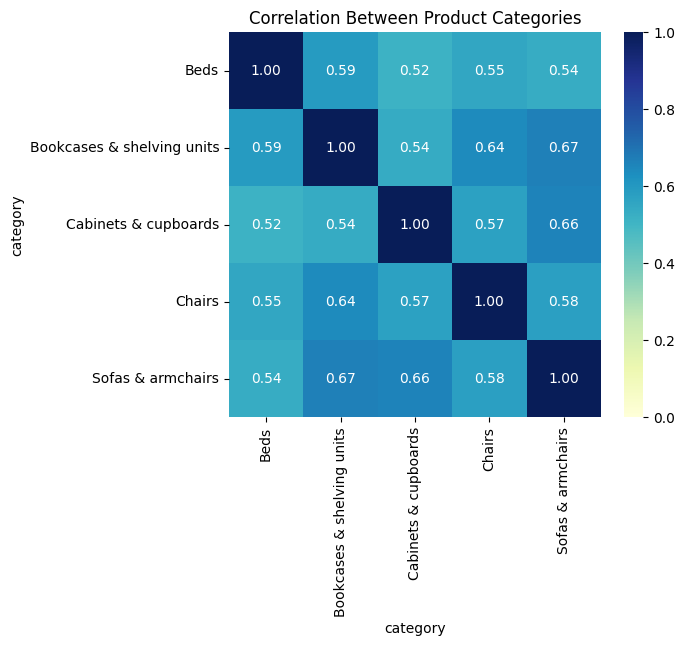

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(category_corr, annot=True, fmt=".2f", cmap='YlGnBu', vmin=0, vmax=1)
plt.title('Correlation Between Product Categories')
plt.show()

In [ ]:
for cat1, cat2 in combinations(category_daily.columns, 2):
    temp = category_daily[[cat1, cat2]].dropna()
    r, p = pearsonr(temp[cat1], temp[cat2])

    #print(f"{cat1} vs {cat2} r = {r:.3f}, p = {p:.3f}")
    print(f"{cat1:<27} vs {cat2:<27}  r = {r:>6.3f}   p = {p:>6.3f}")

Beds                        vs Bookcases & shelving units   r =  0.593   p =  0.000
Beds                        vs Cabinets & cupboards         r =  0.515   p =  0.000
Beds                        vs Chairs                       r =  0.554   p =  0.000
Beds                        vs Sofas & armchairs            r =  0.535   p =  0.000
Bookcases & shelving units  vs Cabinets & cupboards         r =  0.539   p =  0.000
Bookcases & shelving units  vs Chairs                       r =  0.637   p =  0.000
Bookcases & shelving units  vs Sofas & armchairs            r =  0.666   p =  0.000
Cabinets & cupboards        vs Chairs                       r =  0.573   p =  0.000
Cabinets & cupboards        vs Sofas & armchairs            r =  0.658   p =  0.000
Chairs                      vs Sofas & armchairs            r =  0.578   p =  0.000


*   Продажі між топ-5 категоріями товарів демонструють помірну позитивну кореляцію (r ≈ 0.51–0.67), що свідчить про частково узгоджену динаміку їх змін у часі. Найсильніший зв’язок спостерігається між категоріями Bookcases & shelving units, Sofas & armchairs та Cabinets & cupboards, що може вказувати на спільні фактори попиту або комплексні покупки меблів.
*   Усі отримані значення p-value є значно меншими за 0.05, що підтверджує статистичну значущість виявлених взаємозв’язків. Це означає, що кореляції між категоріями не є випадковими та відображають реальні закономірності у поведінці покупців.

## **3.5 Correlation Analysis Between Browsers (Sales)**

In [ ]:
# Aggregation of sales by dates and browsers
selected_browsers = ['Chrome', 'Safari', 'Edge', 'Firefox', 'Android Webview']

browser_daily = (
    df[df['browser'].isin(selected_browsers)]
    .groupby(['date', 'browser'])['price']
    .sum()
    .unstack()
)

browser_daily.head()

browser,Android Webview,Chrome,Edge,Firefox,Safari
date,,,,,
2020-11-01,6716.5,176480.0,6058.0,3187.0,46185.0
2020-11-02,3164.0,228677.3,12404.0,4620.0,99084.5
2020-11-03,3541.0,345273.7,12487.0,14428.0,110632.9
2020-11-04,236.0,228417.8,13671.0,2441.5,88572.8
2020-11-05,5957.0,244978.0,14511.6,7590.0,102691.0


In [ ]:
# Corelation Matrix
browser_corr = browser_daily.corr().round(3)
browser_corr

browser,Android Webview,Chrome,Edge,Firefox,Safari
browser,,,,,
Android Webview,1.000,0.424,0.182,0.028,0.351
Chrome,0.424,1.000,0.593,0.464,0.876
Edge,0.182,0.593,1.000,0.194,0.558
Firefox,0.028,0.464,0.194,1.000,0.469
Safari,0.351,0.876,0.558,0.469,1.000


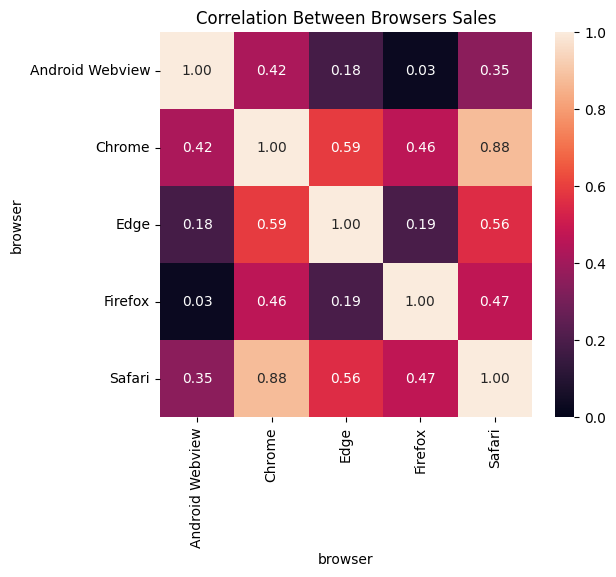

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(browser_corr, annot=True, fmt=".2f", vmin=0, vmax=1)
plt.title('Correlation Between Browsers Sales')
plt.show()

In [ ]:
# Correlation and p-values between browsers
for b1, b2 in combinations(browser_daily.columns, 2):
    temp = browser_daily[[b1, b2]].dropna()
    r, p = pearsonr(temp[b1], temp[b2])

    # print(f"{b1} vs {b2}  r = {r:.3f}, p = {p:.3f}")
    print(f"{b1:<20} vs {b2:<20}  r = {r:>6.3f}   p = {p:>6.3f}")

Android Webview      vs Chrome                r =  0.424   p =  0.000
Android Webview      vs Edge                  r =  0.182   p =  0.083
Android Webview      vs Firefox               r =  0.028   p =  0.791
Android Webview      vs Safari                r =  0.351   p =  0.001
Chrome               vs Edge                  r =  0.593   p =  0.000
Chrome               vs Firefox               r =  0.464   p =  0.000
Chrome               vs Safari                r =  0.876   p =  0.000
Edge                 vs Firefox               r =  0.194   p =  0.063
Edge                 vs Safari                r =  0.558   p =  0.000
Firefox              vs Safari                r =  0.469   p =  0.000


*   Продажі за більшістю браузерів демонструють помірну позитивну кореляцію, що свідчить про наявність спільних факторів впливу, таких як сезонність або загальні зміни попиту. Особливо сильний зв’язок між Chrome та Safari вказує на те, що ці браузери реагують на ринкові зміни подібним чином і формують основний обсяг динаміки продажів.
*   Водночас окремі браузери (зокрема Android Webview, Edge та Firefox) показують слабку або статистично незначущу кореляцію з іншими, що може свідчити про специфічну поведінку користувачів або потенційні проблеми (наприклад, UX чи технічні обмеження). Такі “випадаючі” сегменти потребують додаткового аналізу, оскільки можуть впливати на загальну ефективність продажів.

# **4. Statistical analysis of differences between groups (hypothesis testing)**

## **4.1 Sales Comparison: Verified vs Non-Verified Users**

In [ ]:
#Data preparation, cleaning from NA
df_clean = df.dropna(subset=['is_verified'])

# Aggregation of sales by date
daily_sales = (
    df_clean.groupby(['date', 'is_verified'])['price']
    .sum()
    .unstack()
)
daily_sales.columns = ['non_verified', 'verified'] # Rename columns 0 and 1 to 'non_verified' and 'verified'
daily_sales.head()

,non_verified,verified
date,,
2020-11-01,11030.0,10517.0
2020-11-02,9294.8,35662.0
2020-11-03,4973.0,24177.5
2020-11-04,9167.6,11814.6
2020-11-05,3056.0,22278.6


In [ ]:
# Sample formation
verified = daily_sales['verified'].dropna()            #  registered / verified users
non_verified = daily_sales['non_verified'].dropna()    #  non-verified users

In [ ]:
# Describe Statistics
daily_sales.describe().round(2)

,non_verified,verified
count,88.00,88.00
mean,8142.06,21204.74
std,5624.24,8259.14
min,535.00,3379.00
25%,4762.88,15127.25
50%,7344.50,20633.90
75%,10448.50,25708.55
max,37220.00,44802.40


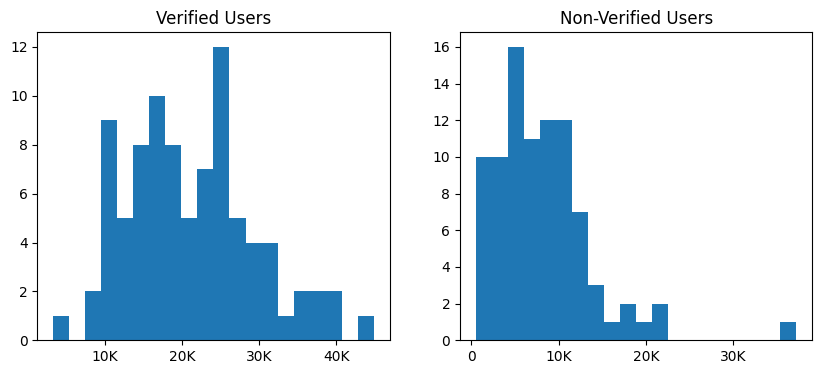

In [ ]:
# Histograms
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(verified, bins=20)
plt.title('Verified Users')
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(format_k))

plt.subplot(1,2,2)
plt.hist(non_verified, bins=20)
plt.title('Non-Verified Users')
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(format_k))

plt.show()

/tmp/ipykernel_19010/2043488750.py:1: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



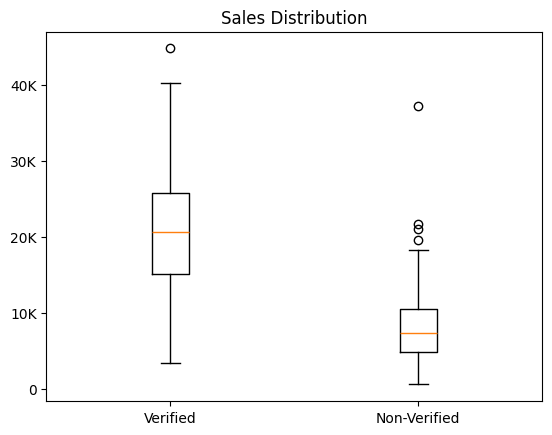

In [ ]:
plt.boxplot([verified, non_verified], labels=['Verified', 'Non-Verified'])
plt.title('Sales Distribution')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(format_k))
plt.show()

*   Продажі серед зареєстрованих користувачів є суттєво вищими, ніж у незареєстрованих, що видно як за середнім значенням (≈21 200 проти ≈8 100), так і за медіаною. Розподіл у групі verified є більш широким і зміщеним у бік більших значень, що свідчить про вищу активність та більшу цінність цих користувачів.

In [ ]:
# Checking the normality of the distribution using the Shapiro test
# H0: The data sample follows a normal distribution (fail to reject H0 if p > 0.05)
# H1: The data sample does not follow a normal distribution (reject H0 if p < 0.05)
stat_v, p_v = shapiro(verified)
stat_nv, p_nv = shapiro(non_verified)

print(f"Verified:      stat = {stat_v:.3f}, p = {p_v:.5f}")
print(f"Non-verified:  stat = {stat_nv:.3f}, p = {p_nv:.5f}")

Verified:      stat = 0.977, p = 0.11326
Non-verified:  stat = 0.863, p = 0.00000


*   Розподіл продажів серед зареєстрованих користувачів не відрізняється статистично значущо від нормального (p ≈ 0.113 > 0.05), що дозволяє вважати його наближеним до нормального. Натомість для незареєстрованих користувачів p-value ≈ 0.000, що свідчить про суттєве відхилення від нормального розподілу.
*   Таким чином, вибірки мають різну форму розподілу, що обґрунтовує використання непараметричних статистичних тестів для подальшого порівняння груп.

*   Оскільки продажі для зареєстрованих і незареєстрованих користувачів агреговані за однаковими датами, кожне спостереження в одній групі має відповідну пару в іншій. Таким чином, вибірки є залежними (парними), що обґрунтовує використання парних статистичних тестів (paired t-test, wilcocson) для встановлення чи є статистично значущою різниця продажів у групах зареєстрованих та незареєстрованих користувачів.
* Тобто виконаємо перевірку гіпотези:  
Н0 - різниця продажів між групами зареєстрованих і незареєстрованих користувачів є статистично значущою, тобто зареєстровані користувачі генерують значно вищі продажі;  
H1 - немає різниці у продажах між цими групами.

Descriptive statistics:
       verified  non_verified      diff
count     88.00         88.00     88.00
mean   21204.74       8142.06  13062.69
std     8259.14       5624.24   9154.01
min     3379.00        535.00  -9750.00
25%    15127.25       4762.88   6732.75
50%    20633.90       7344.50  13031.50
75%    25708.55      10448.50  18555.75
max    44802.40      37220.00  36734.60


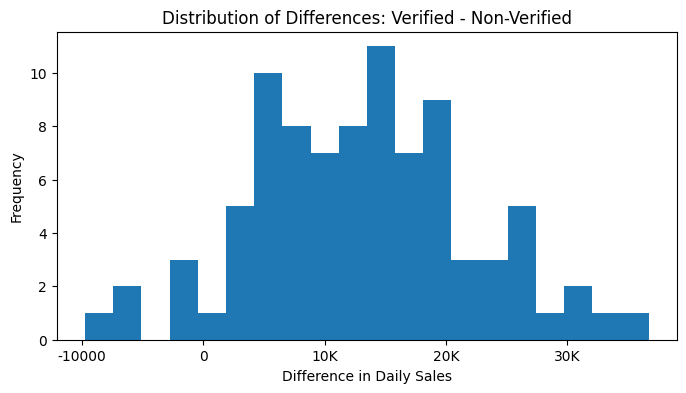

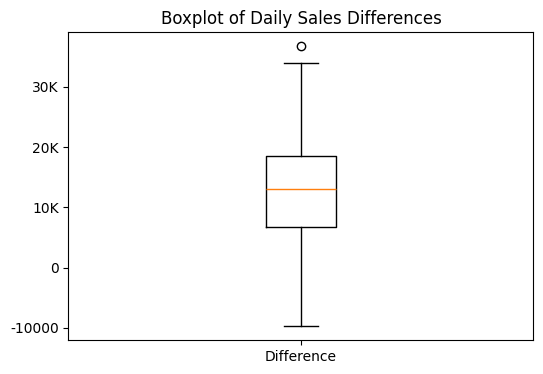

Shapiro test for differences: stat = 0.993, p = 0.93251
Paired t-test: t = 13.386, p = 0.00000


In [ ]:
# 1. Leave only complete paired observations
paired_sales = daily_sales[['verified', 'non_verified']].dropna().copy()

# 2. Create differences
paired_sales['diff'] = paired_sales['verified'] - paired_sales['non_verified']

# 3. Descriptive statistics
print("Descriptive statistics:")
print(paired_sales[['verified', 'non_verified', 'diff']].describe().round(2))

# 4. Histogram of differences
plt.figure(figsize=(8,4))
plt.hist(paired_sales['diff'], bins=20)
plt.title('Distribution of Differences: Verified - Non-Verified')
plt.xlabel('Difference in Daily Sales')
plt.ylabel('Frequency')
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(format_k))
plt.show()

# 5. Boxplot of differences
plt.figure(figsize=(6,4))
plt.boxplot(paired_sales['diff'], tick_labels=['Difference'])
plt.title('Boxplot of Daily Sales Differences')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(format_k))
plt.show()

# 6. Shapiro test for normality of differences
stat_diff, p_diff = shapiro(paired_sales['diff'])
print(f"Shapiro test for differences: stat = {stat_diff:.3f}, p = {p_diff:.5f}")

# 7. Choose the appropriate test
if p_diff > 0.05:
    t_stat, p_val = ttest_rel(paired_sales['verified'], paired_sales['non_verified'])
    print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.5f}")
else:
    w_stat, p_val = wilcoxon(paired_sales['verified'], paired_sales['non_verified'])
    print(f"Wilcoxon signed-rank test: stat = {w_stat:.3f}, p = {p_val:.5f}")

*   Різниця між щоденними продажами зареєстрованих і незареєстрованих користувачів є стабільно додатною, що підтверджується як середнім значенням ~13 063, так і медіаною ~13 032. Розподіл різниць є близьким до нормального (p ≈ 0.93 за тестом Шапіро), що дозволяє коректно застосувати парний t-тест для перевірки гіпотези. Результати t-тесту (t = 13.386, p < 0.05) свідчать про статистично значущу різницю між групами. Візуалізації (гістограма та boxplot) додатково підтверджують, що в більшості днів продажі серед зареєстрованих користувачів суттєво перевищують показники незареєстрованих. Гістограма показує, що майже всі значення різниці додатні, тобто в більшості днів зареєстровані користувачі генерують більше продажів. Boxplot додатково підтверджує це: медіана та основний діапазон значень знаходяться вище нуля, що свідчить про систематичну, а не випадкову перевагу.
*  Зареєстровані користувачі генерують значно вищі продажі, тому бізнесу доцільно інвестувати у механіки стимулювання реєстрації (наприклад, бонуси, персоналізацію, retention-кампанії). Це може суттєво підвищити загальний дохід.

## **4.2 Statistical Analysis of Session Differences Across Traffic Channels**

### **4.2.1 Difference in the number of sessions by traffic channel**

У цьому завданні аналізується кількість сесій у розрізі різних каналів трафіку з метою виявлення можливих відмінностей між ними. Формуються відповідні вибірки для кожного каналу, досліджуються їх розподіли та обирається коректний статистичний тест. За результатами перевіряється, чи є відмінності між каналами статистично значущими.  
*H₀ (нульова)*: кількість сесій однакова для всіх каналів  
*H₁ (альтернативна)*: є відмінності між каналами

Оскільки змінна channel є категоріальною, а аналізу підлягають частоти (кількість сесій), доцільно використовувати χ² тест. Цей тест дозволяє оцінити, чи відрізняється фактичний розподіл сесій між каналами від очікуваного (наприклад, рівномірного). Таким чином, він є відповідним інструментом для перевірки наявності статистично значущих відмінностей між групами.

In [ ]:
# Count sessions by channel
sessions_by_channel = df.groupby('channel')['ga_session_id'].nunique().sort_values(ascending = False)
sessions_by_channel

,ga_session_id
channel,
Organic Search,124425
Paid Search,94341
Direct,81382
Social Search,27914
Undefined,21483


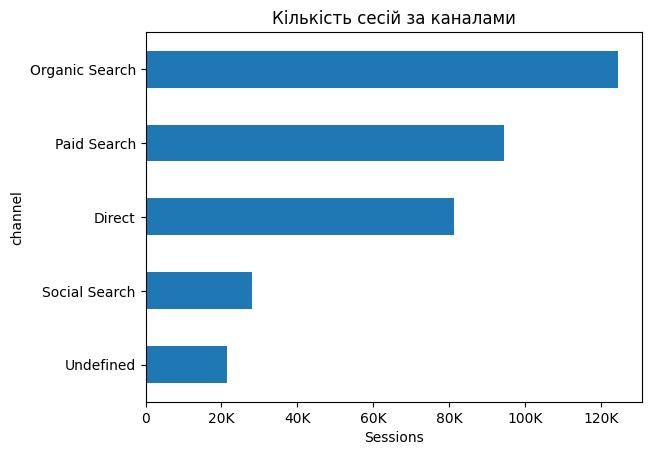

In [ ]:
sessions_by_channel.sort_values().plot(kind='barh')
plt.title("Кількість сесій за каналами")
plt.xlabel("Sessions")
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(format_k))
plt.show()

In [ ]:
# Calculate chisqhare and p-value
observed = sessions_by_channel.values
chi2_stat, p_value = chisquare(observed)
print(f"Chi2 statistic: {chi2_stat}")
print(f"p-value: {p_value}")

Chi2 statistic: 111705.27557253001
p-value: 0.0


In [ ]:
# рівень значущості, тобто наперед задана ймовірність помилки першого роду
alpha = 0.05

if p_value < alpha:
    print("Є статистично значущі відмінності між каналами ")
else:
    print("Немає статистично значущих відмінностей ")

Є статистично значущі відмінності між каналами 


### **4.2.2 Difference in the average check price on sessions between channel**

Припустимо потрібно порівняти не просто кількість сесій, а деяку числову метрику на сесію між каналами трафіку, зокрема середній чек на сесію, використовуючи ANOVA (нормальний розподіл) або Kruskal–Wallis (відмінний від нормального).

Це задача порівняння кількох незалежних груп (каналів трафіку) за однією числовою ознакою — кількістю сесій. Для її розв’язання використовуються методи статистичного тестування (зокрема, тест Краскела–Уоліса або ANOVA залежно від розподілу даних) з метою перевірки наявності значущих відмінностей між групами.   
H₀: розподіли метрики середній чек однаковий у всіх каналах  
H₁: хоча б один канал має інший середній чек


In [ ]:
# Підготуємо дані. Беремо ті рядки, де не пропущені канал і потрібна метрика (у нас price)
df_test = df[['channel', 'price']].dropna()
df_test.head()

,channel,price
0,Paid Search,609.0
1,Organic Search,609.0
2,Direct,189.0
3,Direct,609.0
4,Direct,609.0


In [ ]:
# Number of observations in each channel
df_test['channel'].value_counts()

,count
channel,
Organic Search,11921
Paid Search,9042
Direct,7800
Social Search,2716
Undefined,2059


In [ ]:
# Агрегація до рівня сесії

df_session = df[['ga_session_id', 'channel', 'price']].dropna()

# середній чек у сесії
df_session = df_session.groupby(['ga_session_id', 'channel'])['price'].mean().reset_index()
df_session = df_session.rename(columns={'price': 'mean_price'})
df_session.head()

,ga_session_id,channel,mean_price
0,330355,Paid Search,139.0
1,523799,Organic Search,1315.0
2,1593230,Paid Search,1595.0
3,1613377,Paid Search,985.0
4,2342850,Organic Search,230.0


In [ ]:
# Описова статистика
df_session.groupby('channel')['mean_price'].agg(['count', 'mean', 'median', 'std'])

,count,mean,median,std
channel,,,,
Direct,7800,960.887615,445.0,1332.228340
Organic Search,11921,959.076554,450.0,1311.857270
Paid Search,9042,941.279518,430.0,1306.941294
Social Search,2716,932.292231,445.0,1303.946453
Undefined,2059,971.588635,450.0,1349.991481


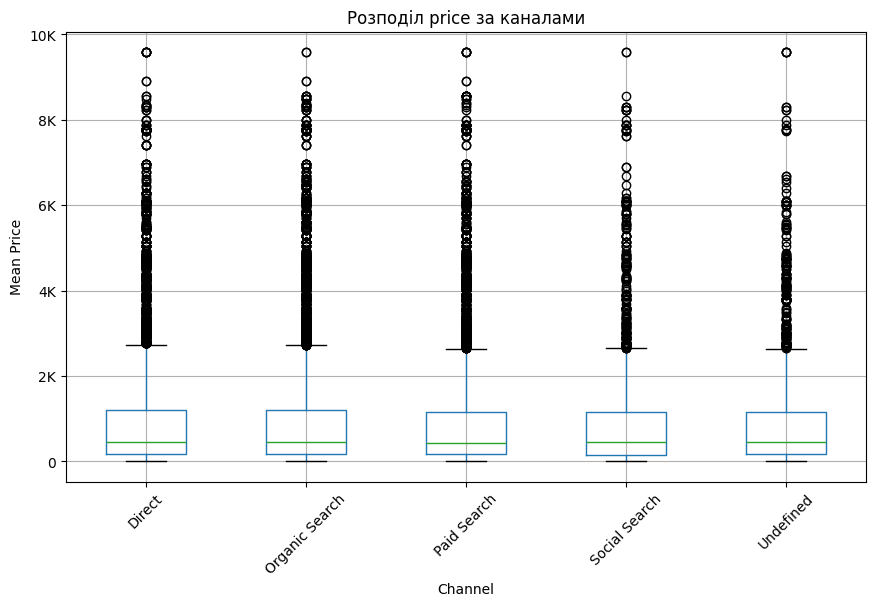

In [ ]:
df_session.boxplot(column='mean_price', by='channel', figsize=(10, 6), rot=45)
plt.title('Розподіл price за каналами')
plt.suptitle('')
plt.xlabel('Channel')
plt.ylabel('Mean Price')
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(format_k))
plt.show()

Розподіл середнього чека сильно скошений вправо (right-skewed),  та містить значну кількість викидів (великих значень (heavy tail)). Медіани по каналах майже однакові (~400–450), середні трохи різняться, але не дуже сильно.  У зв’язку з порушенням припущення нормальності доцільно використати непараметричний тест Kruskal–Wallis.

In [ ]:
# Check normal (Shapiro)

for ch in df_session['channel'].unique():
    sample = df_session[df_session['channel'] == ch]['mean_price']
    sample = sample.sample(min(len(sample), 500), random_state=42)

    stat, p = shapiro(sample)
    print(f'{ch}: p-value = {p:.5f}')

Paid Search: p-value = 0.00000
Organic Search: p-value = 0.00000
Undefined: p-value = 0.00000
Direct: p-value = 0.00000
Social Search: p-value = 0.00000


*  Розподіли відмінні від нормальних p-value значно менші за 0,05.

In [ ]:
# Shoft groups by channels and calculate kruskal-Wallis statistics and p-value

groups = [df_session[df_session['channel'] == ch]['mean_price']
          for ch in df_session['channel'].unique()]

stat, p = kruskal(*groups)

print(f'Kruskal statistics = {stat:.5f}')
print(f'Kruskal p-value = {p:.5f}')

Kruskal statistics = 2.77662
Kruskal p-value = 0.59587


In [ ]:
alpha = 0.05

if p < alpha:
    print("Є статистично значущі відмінності між каналами")
else:
    print("Відмінностей не виявлено")

Відмінностей не виявлено


*   За результатами тесту Kruskal–Wallis (p = 0.596) статистично значущих відмінностей середнього чека між каналами трафіку не виявлено. Це свідчить про те, що канал залучення користувача не має суттєвого впливу на величину покупки в межах сесії.

### **4.2.3 Difference in conversion between channels**

Дослідимо чи відрізняється конверсія сесій у покупку між каналами. Конверсія - частка сесій, у яких була покупка. Вважаємо, що якщо в сесії є хоча б один запис з price, то була покупка.


In [ ]:
# Готуємо дані
df_conv = df[['ga_session_id', 'channel', 'price']].copy()

# Створюємо прапорець покупки
df_conv['is_purchase'] = df_conv['price'].notna().astype(int)

# Агрегуємо до рівня сесій
df_conv_session = (
    df_conv
    .groupby(['ga_session_id', 'channel'])['is_purchase']
    .max()  # якщо хоча б один товар → 1
    .reset_index()
)

In [ ]:
# Рахуємо конверсію по каналах
conversion = df_conv_session.groupby('channel')['is_purchase'].agg(['mean', 'count']).round(3)
conversion = conversion.rename(columns={'mean': 'conversion_rate'})

conversion

,conversion_rate,count
channel,,
Direct,0.096,81382
Organic Search,0.096,124425
Paid Search,0.096,94341
Social Search,0.097,27914
Undefined,0.096,21483


In [ ]:
# Використовуємо тест χ² тест незалежності
contingency = pd.crosstab(
    df_conv_session['channel'],
    df_conv_session['is_purchase']
)

contingency

is_purchase,0,1
channel,,
Direct,73582,7800
Organic Search,112504,11921
Paid Search,85299,9042
Social Search,25198,2716
Undefined,19424,2059


In [ ]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency)
print(f'p-value = {p}')

alpha = 0.05

if p < alpha:
    print("Конверсія залежить від каналу ")
else:
    print("Залежності не виявлено ")

p-value = 0.9585548370612956
Залежності не виявлено 


*   За результатами χ² тесту (p = 0.959) статистично значущої залежності між каналом трафіку та конверсією не виявлено. Це означає, що ймовірність здійснення покупки є практично однаковою для всіх каналів.

## **4.3 Statistical Analysis of Session Differences Across Traffic Channels**

Маємо застосувати статистичний тест для порівняння двох часток, то доцільно обрати z-тест для двох пропорцій.
Перевіримо, чи відрізняється доля сесій з трафіком Organic Search у двох незалежних групах — Europe та Americas.  
H0: доля сесій з трафіком Organic Search у Europe та Americas однакова;  
Н1: доля сесій з трафіком Organic Search у Europe та Americas різна.


In [ ]:
# Вибираємо потрібні регіони
df_region = df[df['continent'].isin(['Europe', 'Americas'])].copy()
df_region['continent'].value_counts()

,count
continent,
Americas,193179
Europe,65135


In [ ]:
# Створюємо змінну “органічна сесія”
df_region['is_organic'] = (df_region['channel'] == 'Organic Search').astype(int)
# Рахуємо агреговані показники
summary = df_region.groupby('continent').agg(
    total_sessions=('ga_session_id', 'count'),
    organic_sessions=('is_organic', 'sum')
)
summary['organic_share'] = summary['organic_sessions'] / summary['total_sessions']
summary

,total_sessions,organic_sessions,organic_share
continent,,,
Americas,193179,68671,0.355479
Europe,65135,23195,0.356107


In [ ]:
europe_total = summary.loc['Europe', 'total_sessions']
europe_organic = summary.loc['Europe', 'organic_sessions']

americas_total = summary.loc['Americas', 'total_sessions']
americas_organic = summary.loc['Americas', 'organic_sessions']

print("Europe share:", europe_organic / europe_total)
print("Americas share:", americas_organic / americas_total)

Europe share: 0.3561065479388961
Americas share: 0.3554785975701293


In [ ]:
# Z-тест для двох пропорцій
counts = np.array([europe_organic, americas_organic])
nobs = np.array([europe_total, americas_total])

z_stat, p_value = proportions_ztest(count=counts, nobs=nobs, alternative='two-sided')

print("z-stat:", z_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Відхиляємо H0 → частки відрізняються статистично значуще")
else:
    print("Не відхиляємо H0 → різниця не є статистично значущою")

z-stat: 0.28951412926103953
p-value: 0.7721879690501752
Не відхиляємо H0 → різниця не є статистично значущою


In [ ]:
# Довірчий інтервал
p1 = europe_organic / europe_total
p2 = americas_organic / americas_total

diff = p1 - p2

se = np.sqrt(p1*(1-p1)/europe_total + p2*(1-p2)/americas_total)

ci_low = diff - 1.96 * se
ci_high = diff + 1.96 * se

print("Різниця часток:", diff)
print("95% CI: [{:.6f}; {:.6f}]".format(ci_low, ci_high))

Різниця часток: 0.0006279503687668386
95% CI: [-0.003624; 0.004880]


*   Отримане значення p-value = 0.772 значно перевищує рівень значущості 0.05, тому немає підстав відхиляти нульову гіпотезу. Це означає, що статистично значущої різниці у частці органічного трафіку між Європою та Америкою не виявлено. Додатково, довірчий інтервал для різниці часток включає 0, що підтверджує відсутність значущих відмінностей між регіонами.

# **5. Аналітичний дашборд у Tableau Public**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df.to_csv('/content/drive/MyDrive/data.csv', index=False)

Mounted at /content/drive


# [Покликання на дашборд ](https://public.tableau.com/views/OnlineStoreSalesAnalysis_17760903294710/Dashboard?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

# **6. Висновки**

1. Проведений EDA показав, що дані є коректно структурованими та не потребують додаткових перетворень, однак значна частка пропущених значень пов’язана з особливостями поведінки користувачів — багато сесій не завершується реєстрацією або покупкою. Аналіз виявив домінування ринку США та англомовної аудиторії, при цьому основний трафік і продажі генеруються через канал Organic Search і десктопні пристрої. Структура продажів визначається насамперед категорією товарів, де лідирують Sofas & armchairs, Chairs і Beds, тоді як канал залучення майже не впливає на середній чек. Загалом результати свідчать про високу концентрацію продажів у ключових сегментах та важливість утримання активних користувачів, оскільки саме вони формують основний обсяг доходу.
2. Проведений статистичний аналіз показав наявність сильної та статистично значущої позитивної кореляції між кількістю сесій і обсягом продажів (r ≈ 0.79), що підтверджує визначальну роль трафіку у формуванні доходу. Також виявлено узгоджену динаміку продажів між континентами, каналами трафіку та основними категоріями товарів, що свідчить про вплив спільних факторів, таких як сезонність і загальний попит, а всі отримані зв’язки є статистично значущими (p < 0.05). Водночас окремі сегменти, зокрема деякі браузери, демонструють слабші або нестабільні зв’язки, що може вказувати на специфіку поведінки користувачів і потребує додаткового дослідження для підвищення ефективності продажів.
3. Проведений статистичний аналіз також показав, що зареєстровані користувачі генерують статистично значно вищі продажі порівняно з незареєстрованими, що підтверджено як описовими метриками, так і результатами t-тесту, а також стабільно додатною різницею у щоденних показниках. Водночас не виявлено статистично значущих відмінностей середнього чека, конверсії та структури трафіку між каналами і регіонами, що свідчить про відносно однорідну поведінку користувачів незалежно від джерела залучення. Отже, ключовим фактором зростання доходу є саме залучення та утримання зареєстрованих користувачів, тоді як оптимізація каналів трафіку має менший вплив на фінансові результати.
4. Створений дашборд також демонструє, що основний обсяг продажів генерується на ринку США через канал Organic Search із домінуванням desktop-пристроїв та браузера Chrome, а найбільший внесок у дохід забезпечують категорії Sofas & armchairs, Chairs і Beds. Водночас поведінка користувачів є стабільною в часі та між сегментами, що підкреслює важливість фокусування на ключових ринках, продуктах і утриманні активної аудиторії для зростання продажів.

